<a href="https://colab.research.google.com/github/mugaruram/MSc.-FIT/blob/main/NDVI_Mann_Kendall_Theil_Sen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project: Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve
Author: Michael Mugarura (2025)

THIRD-PARTY ATTRIBUTIONS (retain when reusing):

Source & Lincense:

*   MIT & BSD-3-Clause usage patterns
*   Part of Code re-authored for thesis.

Thesis citation:
Mugarura, M. (2025). Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve. MSc Thesis, HNEE.



Section 1: Install Required Libraries

In [ ]:
# Install necessary libraries (if not already installed)
!pip install pandas numpy matplotlib scipy
!pip install pymannkendall scipy


Section 2: Data Initialization

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import pymannkendall as mk
from scipy.stats import theilslopes
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
"Cropland Rainfed": [0.098,	0.097,	0.107,	0.079,	0.095,	0.091,	0.094,	0.083,	0.086,	0.089,	0.076,	0.07,	0.067,
                     0.069,	0.079,	0.077,	0.087,	0.082,	0.066,	0.081,	0.084,	0.071,	0.086,	0.079,	0.086,	0.066,
                     0.082,	0.106,	0.087,	0.11,	0.113],
"Mosaic Tree and Shrub": [0.113,	0.104,	0.113,	0.1,	0.116,	0.107,	0.114,	0.099,	0.108,	0.11,	0.085,	0.075,	0.077,
                          0.071,	0.086,	0.083,	0.098,	0.09,	0.075,	0.088,	0.091,	0.084,	0.096,	0.085,	0.09,	0.073,
                          0.085,	0.103,	0.085,	0.093,	0.091],
"Rainfed Herbaceous Crops":	[	0.133,	0.117,	0.128,	0.103,	0.129,	0.119,	0.133,	0.131,	0.133,	0.136,	0.105,	0.096,	0.108,
                             0.097,	0.135,	0.121,	0.138,	0.131,	0.103,	0.131,	0.133,	0.119,	0.14,	0.128,	0.133,	0.1,	0.131,
                              0.147,	0.125,	0.138,	0.14],
"Mosaic Herbaceous Cover":	[0.119,	0.105,	0.112,	0.09,	0.11,	0.101,	0.109,	0.099,	0.109,	0.117,	0.088,	0.067,	0.074,
                            0.071,	0.105, 0.088,	0.11,	0.088,	0.078,	0.097,	0.108,	0.089,	0.093,	0.088,	0.088,	0.069,	0.091,
                            0.115,	0.109,	0.114,	0.118],
"Shrubland":	[0.067,	0.07,	0.072,	0.058,	0.065,	0.067,	0.062,	0.051,	0.054,	0.058,	0.055,	0.053,	0.044,	0.054,
              0.05,	0.059,	0.06,	0.058, 0.048,	0.056,	0.058,	0.044,	0.058,	0.054,	0.057,	0.048,	0.052,	0.073,	0.057,	0.076,	0.076],
"Grassland": [0.084,	0.078,	0.087,	0.07,	0.084,	0.081,	0.085,	0.078,	0.084,	0.086,	0.072,	0.06,	0.062,	0.055,	0.074,	0.069,	0.08,	0.074,
              0.065,	0.073,	0.077,	0.064,	0.073,	0.069,	0.074,	0.06,	0.069,	0.083,	0.071,	0.08,	0.079],
"Sparse Vegetation":  [0.068,	0.069,	0.073,	0.062,	0.069,	0.072,	0.068,	0.058,	0.062,	0.067,	0.057,	0.055,	0.05,	0.055,	0.056,	0.063,	0.067,
                       0.063,	0.053,	0.062,	0.063,	0.052,	0.064,	0.059,	0.063,	0.053,	0.061,	0.077,	0.06,	0.073,	0.07],
"Cropland Irrigated":	[0.149,	0.132,	0.15,	0.117,	0.144,	0.124,	0.143,	0.136,	0.144,	0.143,	0.117,	0.103,	0.114,	0.098,	0.141,
                       0.127,	0.145,	0.133,	0.117,	0.133,	0.143,	0.123,	0.14,	0.138,	0.146,	0.117,	0.135,	0.154,	0.139,	0.153,	0.153],
"Bare Areas":	[0.062,	0.064,	0.067,	0.06,	0.063,	0.068,	0.061,	0.054,	0.055,	0.056,	0.056,	0.051,	0.046,	0.054,	0.048,
               0.055,	0.055,	0.054,	0.045,	0.055,	0.054,	0.045,	0.057,	0.051,	0.052,	0.05,	0.049,	0.059,	0.046,	0.057,	0.06],
"Water Bodies": [0.03,	0.024,	0.035,	0.016,	0.025,	0.017,	0.022,	0.022,	0.019,	0.013,	0.002,	-0.001,	-0.002,	-0.009,	0.014,
                 0.008,	0.018,	0.013,	0.015,	0.021,	0.021,	0.021,	0.027,	0.022,	0.023,	0.014,	0.024,	0.033,	0.03,	0.03,	0.031],
"Mosaic cropland":	[0.134,	0.118,	0.142,	0.117,	0.14,	0.128,	0.144,	0.137,	0.145,	0.144,	0.114,	0.102,	0.107,	0.091,	0.124,	0.119,
                    0.129,	0.124,	0.104,	0.119,	0.128,	0.112,	0.131,	0.122,	0.134,	0.108,	0.122,	0.144,	0.121,	0.13,	0.133],
"Mosaic Natural Vegetation":	[0.14,	0.12,	0.149,	0.117,	0.144,	0.129,	0.143,	0.139,	0.154,	0.151,	0.123,	0.102,	0.109,	0.085,	0.13,
                              0.122,	0.135,	0.129,	0.11,	0.124,	0.136,	0.124,	0.142,	0.134,	0.152,	0.118,	0.133,	0.155,	0.135,	0.148,	0.149],
"Tree Cover Broadleaved Deciduous":	[0.139,	0.125,	0.127,	0.102,	0.161,	0.144,	0.149,	0.171,	0.184,	0.196,	0.193,	0.129,	0.144,	0.077,	0.139,
                                   0.095,	0.085,	0.031,	-0.001,	-0.001,	-0.004,	-0.032,	0.004,	0.02,	0.019,	0.015,	0.033,	0.033,	0.037,	0.039,	0.044],

#"Tree Cover Broadleaved Deciduous": [0.14, 0.126, 0.128, 0.104, 0.161, 0.145, 0.149,	0.171, 0.183, 0.195, 0.12,
#                                     0.117, 0.133, 0.065, 0.128, 0.083,	0.073, 0.019, -0.013, -0.013, -0.019,
#                                     -0.044, -0.008, 0.008, 0.007, 0.003, 0.021, 0.021, 0.025, 0.027,0.032]

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Cropland Rainfed,Mosaic Tree and Shrub,Rainfed Herbaceous Crops,Mosaic Herbaceous Cover,Shrubland,Grassland,Sparse Vegetation,Cropland Irrigated,Bare Areas,Water Bodies,Mosaic cropland,Mosaic Natural Vegetation,Tree Cover Broadleaved Deciduous
0,1990,0.098,0.113,0.133,0.119,0.067,0.084,0.068,0.149,0.062,0.030,0.134,0.140,0.139
1,1991,0.097,0.104,0.117,0.105,0.070,0.078,0.069,0.132,0.064,0.024,0.118,0.120,0.125
2,1992,0.107,0.113,0.128,0.112,0.072,0.087,0.073,0.150,0.067,0.035,0.142,0.149,0.127
3,1993,0.079,0.100,0.103,0.090,0.058,0.070,0.062,0.117,0.060,0.016,0.117,0.117,0.102
4,1994,0.095,0.116,0.129,0.110,0.065,0.084,0.069,0.144,0.063,0.025,0.140,0.144,0.161


In [ ]:
!pip install ace-tools
!pip install ace-tools-open

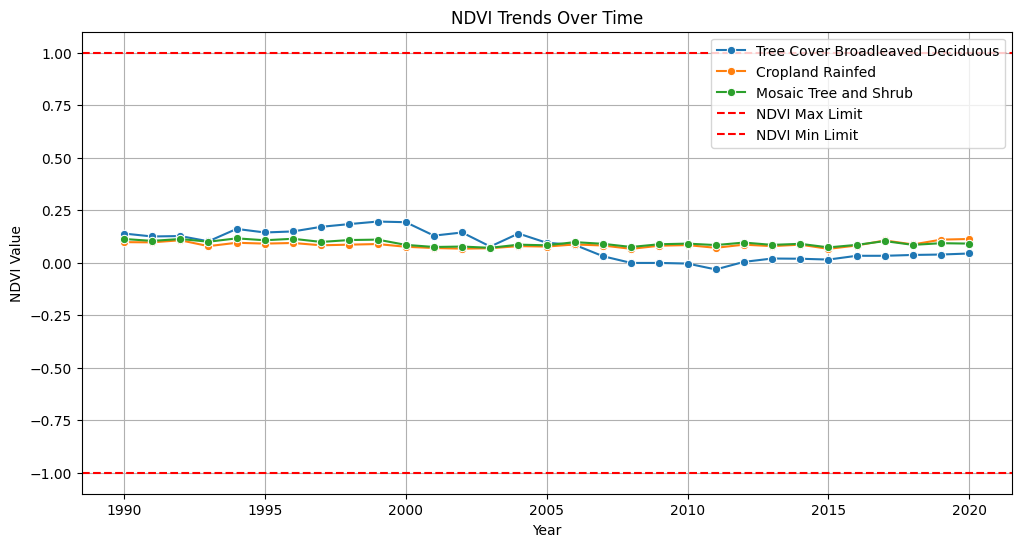

Filtered NDVI Dataset (Outliers Removed)


Loading ITables v2.5.2 from the internet... (need help?)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert Year column to numeric
df["Year"] = pd.to_numeric(df["Year"])  # Changed ndvi_df to df

# Plot NDVI trends over time for each land cover class
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year", y="Tree Cover Broadleaved Deciduous", marker="o", label="Tree Cover Broadleaved Deciduous")  # Changed ndvi_df to df
sns.lineplot(data=df, x="Year", y="Cropland Rainfed", marker="o", label="Cropland Rainfed")  # Changed ndvi_df to df
sns.lineplot(data=df, x="Year", y="Mosaic Tree and Shrub", marker="o", label="Mosaic Tree and Shrub")  # Changed ndvi_df to df

plt.axhline(y=1, color='r', linestyle='--', label="NDVI Max Limit")
plt.axhline(y=-1, color='r', linestyle='--', label="NDVI Min Limit")

plt.xlabel("Year")
plt.ylabel("NDVI Value")
plt.title("NDVI Trends Over Time")
plt.legend()
plt.grid(True)
plt.show()

# --------- Step 2: Apply Outlier Removal ---------
# Define outlier removal function using the IQR (Interquartile Range) method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Apply outlier removal to the Tree Cover Broadleaved Deciduous class
filtered_ndvi_df = remove_outliers(df, "Tree Cover Broadleaved Deciduous") # Changed ndvi_df to df

# Display the filtered dataset
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Filtered NDVI Dataset (Outliers Removed)", dataframe=filtered_ndvi_df)
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Filtered NDVI Dataset (Outliers Removed)", dataframe=filtered_ndvi_df)

*** New NDVI table with outliers filtered***

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import pymannkendall as mk
from scipy.stats import theilslopes
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
"Cropland Rainfed": [0.098,	0.097,	0.107,	0.079,	0.095,	0.091,	0.094,	0.083,	0.086,	0.089,	0.076,	0.07,	0.067,
                     0.069,	0.079,	0.077,	0.087,	0.082,	0.066,	0.081,	0.084,	0.071,	0.086,	0.079,	0.086,	0.066,
                     0.082,	0.106,	0.087,	0.11,	0.113],
"Mosaic Tree and Shrub": [0.113,	0.104,	0.113,	0.1,	0.116,	0.107,	0.114,	0.099,	0.108,	0.11,	0.085,	0.075,	0.077,
                          0.071,	0.086,	0.083,	0.098,	0.09,	0.075,	0.088,	0.091,	0.084,	0.096,	0.085,	0.09,	0.073,
                          0.085,	0.103,	0.085,	0.093,	0.091],
"Rainfed Herbaceous Crops":	[	0.133,	0.117,	0.128,	0.103,	0.129,	0.119,	0.133,	0.131,	0.133,	0.136,	0.105,	0.096,	0.108,
                             0.097,	0.135,	0.121,	0.138,	0.131,	0.103,	0.131,	0.133,	0.119,	0.14,	0.128,	0.133,	0.1,	0.131,
                              0.147,	0.125,	0.138,	0.14],
"Mosaic Herbaceous Cover":	[0.119,	0.105,	0.112,	0.09,	0.11,	0.101,	0.109,	0.099,	0.109,	0.117,	0.088,	0.067,	0.074,
                            0.071,	0.105, 0.088,	0.11,	0.088,	0.078,	0.097,	0.108,	0.089,	0.093,	0.088,	0.088,	0.069,	0.091,
                            0.115,	0.109,	0.114,	0.118],
"Shrubland":	[0.067,	0.07,	0.072,	0.058,	0.065,	0.067,	0.062,	0.051,	0.054,	0.058,	0.055,	0.053,	0.044,	0.054,
              0.05,	0.059,	0.06,	0.058, 0.048,	0.056,	0.058,	0.044,	0.058,	0.054,	0.057,	0.048,	0.052,	0.073,	0.057,	0.076,	0.076],
"Grassland": [0.084,	0.078,	0.087,	0.07,	0.084,	0.081,	0.085,	0.078,	0.084,	0.086,	0.072,	0.06,	0.062,	0.055,	0.074,	0.069,	0.08,	0.074,
              0.065,	0.073,	0.077,	0.064,	0.073,	0.069,	0.074,	0.06,	0.069,	0.083,	0.071,	0.08,	0.079],
"Sparse Vegetation":  [0.068,	0.069,	0.073,	0.062,	0.069,	0.072,	0.068,	0.058,	0.062,	0.067,	0.057,	0.055,	0.05,	0.055,	0.056,	0.063,	0.067,
                       0.063,	0.053,	0.062,	0.063,	0.052,	0.064,	0.059,	0.063,	0.053,	0.061,	0.077,	0.06,	0.073,	0.07],
"Cropland Irrigated":	[0.149,	0.132,	0.15,	0.117,	0.144,	0.124,	0.143,	0.136,	0.144,	0.143,	0.117,	0.103,	0.114,	0.098,	0.141,
                       0.127,	0.145,	0.133,	0.117,	0.133,	0.143,	0.123,	0.14,	0.138,	0.146,	0.117,	0.135,	0.154,	0.139,	0.153,	0.153],
"Bare Areas":	[0.062,	0.064,	0.067,	0.06,	0.063,	0.068,	0.061,	0.054,	0.055,	0.056,	0.056,	0.051,	0.046,	0.054,	0.048,
               0.055,	0.055,	0.054,	0.045,	0.055,	0.054,	0.045,	0.057,	0.051,	0.052,	0.05,	0.049,	0.059,	0.046,	0.057,	0.06],
"Water Bodies": [0.03,	0.024,	0.035,	0.016,	0.025,	0.017,	0.022,	0.022,	0.019,	0.013,	0.002,	-0.001,	-0.002,	-0.009,	0.014,
                 0.008,	0.018,	0.013,	0.015,	0.021,	0.021,	0.021,	0.027,	0.022,	0.023,	0.014,	0.024,	0.033,	0.03,	0.03,	0.031],
"Mosaic cropland":	[0.134,	0.118,	0.142,	0.117,	0.14,	0.128,	0.144,	0.137,	0.145,	0.144,	0.114,	0.102,	0.107,	0.091,	0.124,	0.119,
                    0.129,	0.124,	0.104,	0.119,	0.128,	0.112,	0.131,	0.122,	0.134,	0.108,	0.122,	0.144,	0.121,	0.13,	0.133],
"Mosaic Natural Vegetation":	[0.14,	0.12,	0.149,	0.117,	0.144,	0.129,	0.143,	0.139,	0.154,	0.151,	0.123,	0.102,	0.109,	0.085,	0.13,
                              0.122,	0.135,	0.129,	0.11,	0.124,	0.136,	0.124,	0.142,	0.134,	0.152,	0.118,	0.133,	0.155,	0.135,	0.148,	0.149],
"Tree Cover Broadleaved Deciduous":	[0.139,	0.125,	0.127,	0.102,	0.161,	0.144,	0.149,	0.171,	0.184,	0.196,	0.193,	0.129,	0.144,	0.077,	0.139,
                                   0.095,	0.085,	0.031,	-0.001,	-0.001,	-0.004,	-0.032,	0.004,	0.02,	0.019,	0.015,	0.033,	0.033,	0.037,	0.039,	0.044],

#"Tree Cover Broadleaved Deciduous": [0.14, 0.126, 0.128, 0.104, 0.161, 0.145, 0.149, 0.171, 0.183, 0.195, 0.12,
#                                     0.117, 0.133, 0.065, 0.128, 0.083, 0.073, 0.019, -0.013, -0.013, -0.019,
#                                    -0.044, -0.008, 0.008, 0.007, 0.003, 0.021, 0.021, 0.025, 0.027, 0.032]  #Use this for new outliers, but there are not necesarilly since all NDVI values are in the right range
      # Add more classes as needed
}


In [6]:
# prompt: Using dataframe df: variance

# Calculate the variance for each column in the DataFrame
variances = df.var()

# Print the variances
variances


,0
Year,82.666667
Cropland Rainfed,0.000163
Mosaic Tree and Shrub,0.000171
Rainfed Herbaceous Crops,0.000201
Mosaic Herbaceous Cover,0.000234
Shrubland,0.000076
Grassland,0.000073
Sparse Vegetation,0.000048
Cropland Irrigated,0.000218
Bare Areas,0.000038


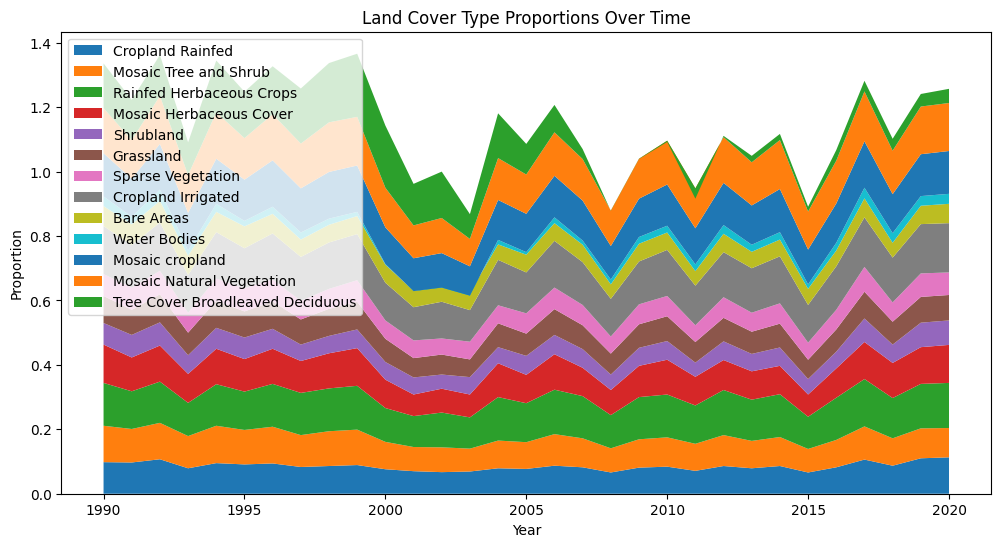

In [7]:
# @title Land Cover Type Proportions Over Time

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.stackplot(df['Year'],
              df['Cropland Rainfed'],
              df['Mosaic Tree and Shrub'],
              df['Rainfed Herbaceous Crops'],
              df['Mosaic Herbaceous Cover'],
              df['Shrubland'],
              df['Grassland'],
              df['Sparse Vegetation'],
              df['Cropland Irrigated'],
              df['Bare Areas'],
              df['Water Bodies'],
              df['Mosaic cropland'],
              df['Mosaic Natural Vegetation'],
              df['Tree Cover Broadleaved Deciduous'],
              labels=['Cropland Rainfed', 'Mosaic Tree and Shrub', 'Rainfed Herbaceous Crops', 'Mosaic Herbaceous Cover', 'Shrubland', 'Grassland', 'Sparse Vegetation', 'Cropland Irrigated', 'Bare Areas', 'Water Bodies', 'Mosaic cropland', 'Mosaic Natural Vegetation', 'Tree Cover Broadleaved Deciduous'])
plt.legend(loc='upper left')
plt.title('Land Cover Type Proportions Over Time')
plt.xlabel('Year')
_ = plt.ylabel('Proportion')

Section 3: Mann-Kendall Test and Sen’s Slope Functions

In [8]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


Section 4: Perform Analysis

In [9]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Cropland Rainfed,No Trend,0.551333,-0.595764,-0.000222
Mosaic Tree and Shrub,Decreasing,0.014207,-2.451974,-0.00076
Rainfed Herbaceous Crops,No Trend,0.091015,1.690066,0.000318
Mosaic Herbaceous Cover,No Trend,0.573639,-0.5627,-0.000115
Shrubland,No Trend,0.322458,-0.989419,-0.0002
Grassland,No Trend,0.079356,-1.754436,-0.000308
Sparse Vegetation,No Trend,0.366417,-0.903205,-0.000208
Cropland Irrigated,No Trend,0.413562,0.817641,0.0002
Bare Areas,Decreasing,0.00516,-2.796854,-0.0004
Water Bodies,No Trend,0.162554,1.396533,0.000313


<Figure size 800x600 with 0 Axes>

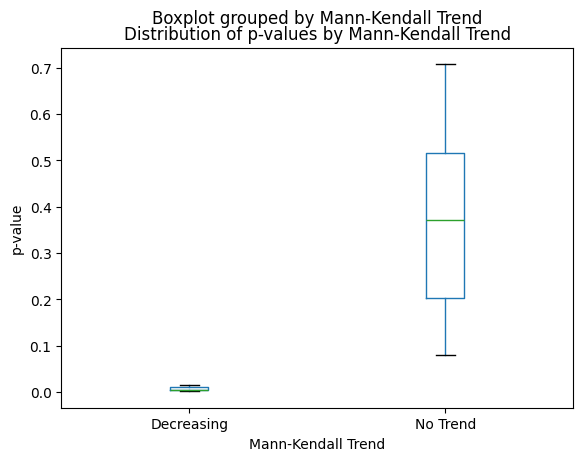

In [10]:
# @title Distribution of p-values by Mann-Kendall Trend

import matplotlib.pyplot as plt

# Assuming your data is in a pandas DataFrame called 'results_df'

plt.figure(figsize=(8, 6))
results_df.boxplot(column='p-value', by='Mann-Kendall Trend', grid=False)
plt.title('Distribution of p-values by Mann-Kendall Trend')
plt.xlabel('Mann-Kendall Trend')
_ = plt.ylabel('p-value')

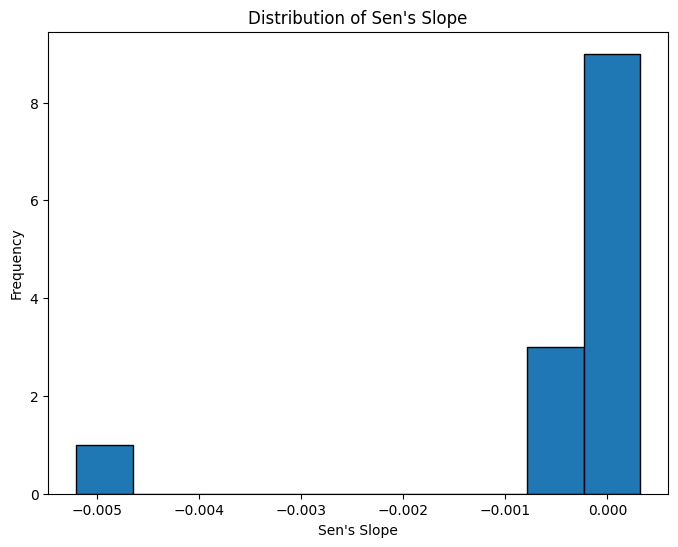

In [11]:
# @title Distribution of Sen's Slope

import matplotlib.pyplot as plt

# Assuming your data is in a pandas DataFrame called 'results_df'

plt.figure(figsize=(8, 6))
plt.hist(results_df["Sen's Slope"], bins=10, edgecolor='black')
plt.title("Distribution of Sen's Slope")
plt.xlabel("Sen's Slope")
_ = plt.ylabel('Frequency')


In [ ]:
!pip install ace-tools
!pip install ace-tools-open

# ** Analysing the three classes dataframe to analyse if they are out of range **

*** Statistical Analysis Results for class NDVI Trends with 1990 as starting point***

In [13]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from scipy.stats import theilslopes

# Create a DataFrame from the provided data dictionary
df = pd.DataFrame(data)

# Ensure the Year column is treated as numeric
df["Year"] = pd.to_numeric(df["Year"])

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        "Sen's Slope": slope,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results for review
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Updated Statistical Analysis of NDVI Trends", dataframe=results_df)


Updated Statistical Analysis of NDVI Trends


Loading ITables v2.5.2 from the internet... (need help?)


In [14]:
# Display the analysis results in the output
print("\nUpdated Statistical Analysis of NDVI Trends:")
results_df


Updated Statistical Analysis of NDVI Trends:


,Mann-Kendall Trend,P-Value,Z-Statistic,Adjusted Intercept,Sen's Slope,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.551333,-0.595764,0.087778,-0.000222,-0.0007,0.000478
Mosaic Tree and Shrub,decreasing,0.014207,-2.451974,0.10476,-0.00076,-0.00125,-0.0002
Rainfed Herbaceous Crops,no trend,0.091015,1.690066,0.125364,0.000318,0.0,0.000857
Mosaic Herbaceous Cover,no trend,0.573639,-0.5627,0.099808,-0.000115,-0.00095,0.000409
Shrubland,no trend,0.322458,-0.989419,0.0614,-0.0002,-0.000571,0.0002
Grassland,no trend,0.079356,-1.754436,0.079615,-0.000308,-0.000667,0.0
Sparse Vegetation,no trend,0.366417,-0.903205,0.066417,-0.000208,-0.000455,0.00016
Cropland Irrigated,no trend,0.413562,0.817641,0.1334,0.0002,-0.000333,0.000846
Bare Areas,decreasing,0.00516,-2.796854,0.061,-0.0004,-0.0006,-0.000138
Water Bodies,no trend,0.162554,1.396533,0.015062,0.000313,-0.000091,0.000727


**Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class.**

In [15]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results for review
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Updated NDVI Trend Analysis with Standard Deviations", dataframe=results_df)

# Display the analysis results in the output
print("\nUpdated NDVI Trend Analysis with Standard Deviations:")
results_df


Updated NDVI Trend Analysis with Standard Deviations:


,Mann-Kendall Trend,P-Value,P-Value Std,Z-Statistic,Adjusted Intercept,Intercept Std,Sen's Slope,Sen Slope Std,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.551333,0.0,-0.595764,0.087778,0.012723,-0.000222,0.000589,-0.0007,0.000478
Mosaic Tree and Shrub,decreasing,0.014207,0.0,-2.451974,0.10476,0.010829,-0.00076,0.000525,-0.00125,-0.0002
Rainfed Herbaceous Crops,no trend,0.091015,0.0,1.690066,0.125364,0.013526,0.000318,0.000429,0.0,0.000857
Mosaic Herbaceous Cover,no trend,0.573639,0.0,-0.5627,0.099808,0.014971,-0.000115,0.00068,-0.00095,0.000409
Shrubland,no trend,0.322458,0.0,-0.989419,0.0614,0.008624,-0.0002,0.000386,-0.000571,0.0002
Grassland,no trend,0.079356,0.0,-1.754436,0.079615,0.00798,-0.000308,0.000333,-0.000667,0.0
Sparse Vegetation,no trend,0.366417,0.0,-0.903205,0.066417,0.006869,-0.000208,0.000307,-0.000455,0.00016
Cropland Irrigated,no trend,0.413562,0.0,0.817641,0.1334,0.014306,0.0002,0.00059,-0.000333,0.000846
Bare Areas,decreasing,0.00516,0.0,-2.796854,0.061,0.005134,-0.0004,0.000231,-0.0006,-0.000138
Water Bodies,no trend,0.162554,0.0,1.396533,0.015062,0.010191,0.000313,0.000409,-0.000091,0.000727


***Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class and eport as CSV to file**


In [16]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results
print(results_df)

# Save results as a CSV file for review
results_df.to_csv("Updated_NDVI_Trend_Analysis.csv", index=True)


                                 Mann-Kendall Trend   P-Value P-Value Std  \
Cropland Rainfed                           no trend  0.551333         0.0   
Mosaic Tree and Shrub                    decreasing  0.014207         0.0   
Rainfed Herbaceous Crops                   no trend  0.091015         0.0   
Mosaic Herbaceous Cover                    no trend  0.573639         0.0   
Shrubland                                  no trend  0.322458         0.0   
Grassland                                  no trend  0.079356         0.0   
Sparse Vegetation                          no trend  0.366417         0.0   
Cropland Irrigated                         no trend  0.413562         0.0   
Bare Areas                               decreasing   0.00516         0.0   
Water Bodies                               no trend  0.162554         0.0   
Mosaic cropland                            no trend  0.708114         0.0   
Mosaic Natural Vegetation                  no trend  0.376521         0.0   

**Visualize NDVI trends over time:**

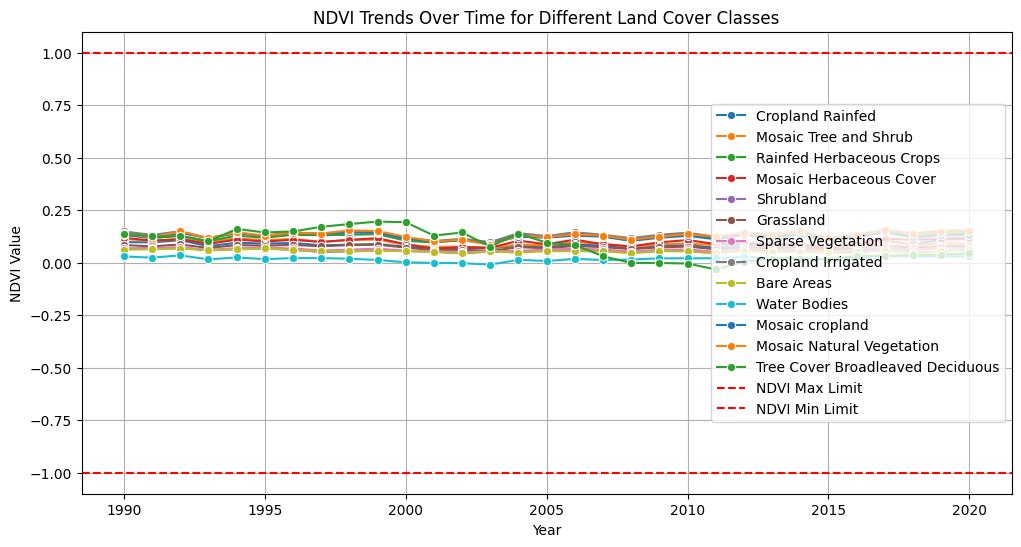

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(12, 6))

# Plot NDVI trends over time for each land cover class
for col in df.columns[1:]:  # Skip the 'Year' column
    sns.lineplot(data=df, x="Year", y=col, marker="o", label=col)

# Add reference lines for valid NDVI range (-1 to 1)
plt.axhline(y=1, color='r', linestyle='--', label="NDVI Max Limit")
plt.axhline(y=-1, color='r', linestyle='--', label="NDVI Min Limit")

# Set labels and title
plt.xlabel("Year")
plt.ylabel("NDVI Value")
plt.title("NDVI Trends Over Time for Different Land Cover Classes")
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()


Section 5: Visualization (Optional)

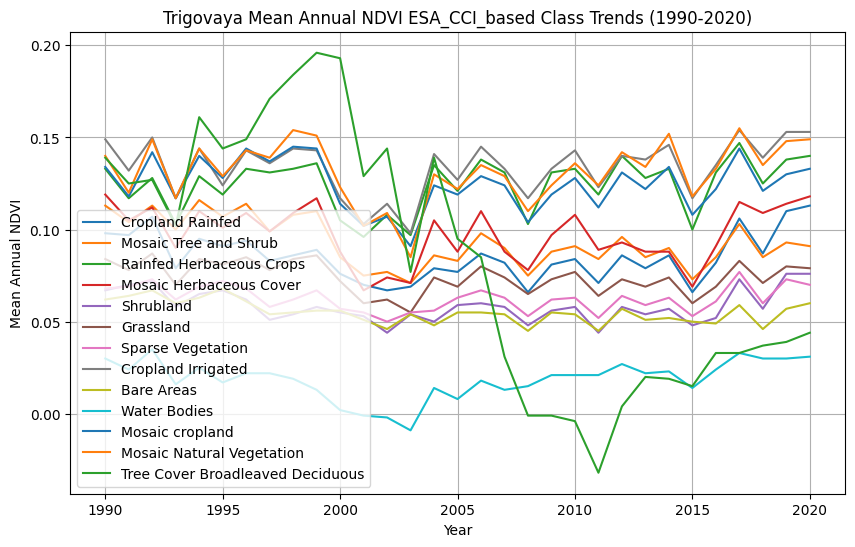

In [18]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("Trigovaya Mean Annual NDVI ESA_CCI_based Class Trends (1990-2020)")
plt.xlabel("Year")
plt.ylabel("Mean Annual NDVI")
plt.legend()
plt.grid()
plt.show()


In [19]:
import pandas as pd

# Example 1: Select specific columns
selected_columns = ["Year", "Mosaic Tree and Shrub", "Bare Areas","Tree Cover Broadleaved Deciduous"]
rdf = df[selected_columns]
print("\nReduced DataFrame (selected columns):")
#print(rdf)
# rdf
rdf.head()


Reduced DataFrame (selected columns):


,Year,Mosaic Tree and Shrub,Bare Areas,Tree Cover Broadleaved Deciduous
0,1990,0.113,0.062,0.139
1,1991,0.104,0.064,0.125
2,1992,0.113,0.067,0.127
3,1993,0.100,0.060,0.102
4,1994,0.116,0.063,0.161


## Analysis for significant class Annual trends

In [20]:
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
"Mosaic Tree and Shrub": [0.113,	0.104,	0.113,	0.1,	0.116,	0.107,	0.114,	0.099,	0.108,	0.11,	0.085,	0.075,	0.077,
                          0.071,	0.086,	0.083,	0.098,	0.09,	0.075,	0.088,	0.091,	0.084,	0.096,	0.085,	0.09,	0.073,
                          0.085,	0.103,	0.085,	0.093,	0.091],
"Bare Areas":	[0.062,	0.064,	0.067,	0.06,	0.063,	0.068,	0.061,	0.054,	0.055,	0.056,	0.056,	0.051,	0.046,	0.054,	0.048,
               0.055,	0.055,	0.054,	0.045,	0.055,	0.054,	0.045,	0.057,	0.051,	0.052,	0.05,	0.049,	0.059,	0.046,	0.057,	0.06],
"Tree Cover Broadleaved Deciduous":	[0.139,	0.125,	0.127,	0.102,	0.161,	0.144,	0.149,	0.171,	0.184,	0.196,	0.193,	0.129,	0.144,	0.077,	0.139,
                                     0.095,	0.085,	0.031,	-0.001,	-0.001,	-0.004,	-0.032,	0.004,	0.02,	0.019,	0.015,	0.033,	0.033,	0.037,	0.039,	0.044],


    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Mosaic Tree and Shrub,Bare Areas,Tree Cover Broadleaved Deciduous
0,1990,0.113,0.062,0.139
1,1991,0.104,0.064,0.125
2,1992,0.113,0.067,0.127
3,1993,0.100,0.060,0.102
4,1994,0.116,0.063,0.161


In [21]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


In [22]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope,
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Mosaic Tree and Shrub,Decreasing,0.014207,-2.451974,-0.00076
Bare Areas,Decreasing,0.00516,-2.796854,-0.0004
Tree Cover Broadleaved Deciduous,Decreasing,0.001233,-3.231187,-0.0052


Deeper anaylsis

In [23]:

# Create a DataFrame from the data dictionary
df = pd.DataFrame(data)

# Display the DataFrame
print("NDVI Class Trends analysis:")
df.head()

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, df['Year'])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'Slope': slope,
        'Intercept': intercept,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results in the output
print("\nStatistical Analysis Results for class NDVI Trends:")
results_df

NDVI Class Trends analysis:

Statistical Analysis Results for class NDVI Trends:


,Mann-Kendall Trend,P-Value,Slope,Intercept,Lower Slope,Upper Slope
Mosaic Tree and Shrub,decreasing,0.014207,-0.00076,1.6148,-0.00125,-0.0002
Bare Areas,decreasing,0.00516,-0.0004,0.857,-0.0006,-0.000138
Tree Cover Broadleaved Deciduous,decreasing,0.001233,-0.0052,10.511,-0.007412,-0.003071


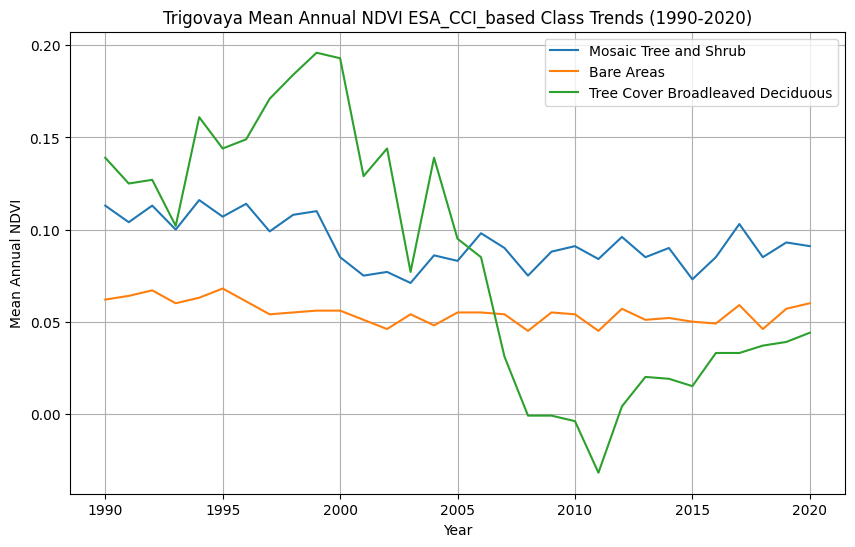

In [24]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("Trigovaya Mean Annual NDVI ESA_CCI_based Class Trends (1990-2020)")
plt.xlabel("Year")
plt.ylabel("Mean Annual NDVI")
plt.legend()
plt.grid()
plt.show()


## **Target Years (1990, 2000, 2010, 2020) for Annual**

Section 2: Data Initialization

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 2000, 2010, 2020],
    "Cropland Rainfed": [0.098,	0.076, 0.084, 0.113],
"Mosaic Tree and Shrub": [0.113, 0.085,	0.091, 0.091],
"Rainfed Herbaceous Crops":	[0.133,	0.105, 0.133,	0.14],
"Mosaic Herbaceous Cover":	[0.119,	0.088, 0.108,	0.118],
"Shrubland":	[0.067,	0.055,	0.058, 0.076],
"Grassland": [0.084, 0.072,	0.077, 0.079],
"Sparse Vegetation":  [0.068,	0.057, 0.063,	0.07],
"Cropland Irrigated":	[0.149,	0.117, 0.143, 0.153],
"Bare Areas":	[0.062,	0.056, 0.054,	0.06],
"Water Bodies": [0.03, 0.002,	0.021, 0.031],
"Mosaic cropland":	[0.134,	0.114, 0.128, 0.133],
"Mosaic Natural Vegetation":	[0.14, 0.123, 0.136, 0.149],
"Tree Cover Broadleaved Deciduous":	[0.139,	0.193, -0.004, 0.044],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Cropland Rainfed,Mosaic Tree and Shrub,Rainfed Herbaceous Crops,Mosaic Herbaceous Cover,Shrubland,Grassland,Sparse Vegetation,Cropland Irrigated,Bare Areas,Water Bodies,Mosaic cropland,Mosaic Natural Vegetation,Tree Cover Broadleaved Deciduous
0,1990,0.098,0.113,0.133,0.119,0.067,0.084,0.068,0.149,0.062,0.030,0.134,0.140,0.139
1,2000,0.076,0.085,0.105,0.088,0.055,0.072,0.057,0.117,0.056,0.002,0.114,0.123,0.193
2,2010,0.084,0.091,0.133,0.108,0.058,0.077,0.063,0.143,0.054,0.021,0.128,0.136,-0.004
3,2020,0.113,0.091,0.140,0.118,0.076,0.079,0.070,0.153,0.060,0.031,0.133,0.149,0.044


Section 3: Mann-Kendall Test and Sen’s Slope Functions

In [26]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


Section 4: Perform Analysis

In [27]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Cropland Rainfed,No Trend,0.734095,0.339683,0.00065
Mosaic Tree and Shrub,No Trend,1.0,0.0,-0.000367
Rainfed Herbaceous Crops,No Trend,0.470101,0.722315,0.000467
Mosaic Herbaceous Cover,No Trend,1.0,0,0.000483
Shrubland,No Trend,0.734095,0.339683,0.0003
Grassland,No Trend,1.0,0,0.000017
Sparse Vegetation,No Trend,0.734095,0.339683,0.000333
Cropland Irrigated,No Trend,0.734095,0.339683,0.000567
Bare Areas,No Trend,0.734095,-0.339683,-0.000133
Water Bodies,No Trend,0.734095,0.339683,0.000517


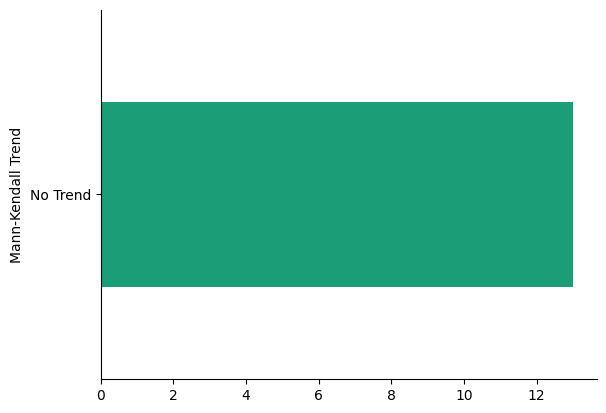

In [28]:
# @title Mann-Kendall Trend

from matplotlib import pyplot as plt
import seaborn as sns
results_df.groupby('Mann-Kendall Trend').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

# **WINTER**

Section 2: Data Initialization

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau

# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],

"Cropland Rainfed": [	0.076,	0.067,	0.076,	0.085,	0.124,	0.097,	0.06,	0.045,	0.015,	0.07,	0.093,	0.073,	0.076,	0.074,	0.078,	0.099,	0.106,	0.092,	0.066,	0.083,	0.12,	0.051,	0.082,	0.041,	0.039,	0.07,	0.081,	0.072,	0.046,	0.098,	0.063],
"Mosaic Tree and Shrub": [	0.047,	0.045,	0.0485,	0.052,	0.065,	0.058,	0.049,	0.051,	0.016,	0.041,	0.052,	0.047,	0.049,	0.05,	0.046,	0.056,	0.059,	0.055,	0.048,	0.057,	0.069,	0.045,	0.051,	0.031,	0.035,	0.053,	0.06,	0.045,	0.049,	0.062,	0.054],
"Rainfed Herbaceous Crops": [	0.038,	0.039,	0.0425,	0.046,	0.065,	0.052,	0.044,	0.045,	0.007,	0.043,	0.049,	0.042,	0.047,	0.05,	0.051,	0.055,	0.06,	0.057,	0.054,	0.062,	0.067,	0.049,	0.05,	0.03,	0.033,	0.05,	0.054,	0.044,	0.055,	0.05,	0.058],
"Mosaic Herbaceous Cover": [	0.029,	0.028,	0.03,	0.032,	0.034,	0.035,	0.028,	0.029,	0,	0.016,	0.026,	0.031,	0.032,	0.028,	0.023,	0.027,	0.027,	0.032,	0.03,	0.034,	0.035,	0.024,	0.03,	0.017,	0.023,	0.032,	0.034,	0.024,	0.026,	0.033,	0.034],
"Shrubland": [	0.1,	0.087,	0.132,	0.107,	0.151,	0.116,	0.061,	0.043,	0.018,	0.084,	0.117,	0.083,	0.09,	0.086,	0.095,	0.128,	0.121,	0.12,	0.076,	0.096,	0.168,	0.056,	0.106,	0.057,	0.049,	0.085,	0.107,	0.088,	0.049,	0.137,	0.067],
"Grassland": [	0.046,	0.041,	0.0455,	0.05,	0.062,	0.056,	0.036,	0.035,	0.007,	0.038,	0.049,	0.041,	0.044,	0.043,	0.038,	0.049,	0.05,	0.051,	0.041,	0.045,	0.061,	0.032,	0.044,	0.022,	0.025,	0.043,	0.048,	0.036,	0.033,	0.051,	0.04],
"Sparse Vegetation": [	0.08,	0.066,	0.112,	0.084,	0.117,	0.091,	0.051,	0.041,	0.024,	0.065,	0.088,	0.066,	0.07,	0.066,	0.076,	0.099,	0.092,	0.089,	0.062,	0.077,	0.133,	0.049,	0.083,	0.046,	0.041,	0.076,	0.092,	0.069,	0.047,	0.109,	0.059],
"Cropland Irrigated": [	0.044,	0.042,	0.0475,	0.053,	0.085,	0.065,	0.047,	0.047,	0.027,	0.053,	0.06,	0.049,	0.055,	0.053,	0.058,	0.062,	0.071,	0.059,	0.052,	0.062,	0.071,	0.045,	0.052,	0.028,	0.026,	0.053,	0.061,	0.052,	0.047,	0.06,	0.064],
"Bare Areas": [	0.114,	0.092,	0.11,	0.128,	0.185,	0.139,	0.077,	0.047,	0.033,	0.143,	0.13,	0.11,	0.109,	0.099,	0.121,	0.124,	0.127,	0.121,	0.079,	0.107,	0.155,	0.063,	0.109,	0.055,	0.041,	0.095,	0.12,	0.09,	0.049,	0.128,	0.077],
"Water Bodies": [	-0.037,	-0.029,	-0.027,	-0.025,	-0.007,	-0.025,	-0.035,	-0.032,	-0.036,	-0.034,	-0.037,	-0.038,	-0.031,	-0.038,	-0.028,	-0.033,	-0.025,	-0.038,	-0.017,	-0.016,	-0.013,	-0.027,	-0.017,	-0.015,	-0.019,	-0.026,	-0.027,	-0.021,	-0.019,	-0.035,	-0.021],
"Mosaic cropland": [	0.048,	0.047,	0.051,	0.055,	0.067,	0.062,	0.055,	0.057,	0.031,	0.052,	0.056,	0.051,	0.055,	0.057,	0.055,	0.061,	0.065,	0.06,	0.056,	0.065,	0.075,	0.052,	0.055,	0.032,	0.034,	0.059,	0.064,	0.052,	0.054,	0.061,	0.061],
"Mosaic Natural Vegetation": [	0.048,	0.044,	0.049,	0.054,	0.066,	0.063,	0.05,	0.048,	0.028,	0.055,	0.054,	0.052,	0.053,	0.054,	0.051,	0.053,	0.057,	0.056,	0.051,	0.06,	0.066,	0.046,	0.045,	0.026,	0.028,	0.05,	0.053,	0.045,	0.044,	0.048,	0.053],
"Tree Cover Broadleaved Deciduous": [	0.043,	0.033,	0.036,	0.039,	0.055,	0.047,	0.047,	0.044,	-0.01,	0.019,	0.041,	0.04,	0.045,	0.048,	0.012,	0.029,	-0.028,	-0.039,	-0.05,	-0.049,	0.035,	-0.013,	-0.007,	0,	-0.003,	0.008,	0.004,	0,	0.027,	0.03,	0.012],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Cropland Rainfed,Mosaic Tree and Shrub,Rainfed Herbaceous Crops,Mosaic Herbaceous Cover,Shrubland,Grassland,Sparse Vegetation,Cropland Irrigated,Bare Areas,Water Bodies,Mosaic cropland,Mosaic Natural Vegetation,Tree Cover Broadleaved Deciduous
0,1990,0.076,0.0470,0.0380,0.029,0.100,0.0460,0.080,0.0440,0.114,-0.037,0.048,0.048,0.043
1,1991,0.067,0.0450,0.0390,0.028,0.087,0.0410,0.066,0.0420,0.092,-0.029,0.047,0.044,0.033
2,1992,0.076,0.0485,0.0425,0.030,0.132,0.0455,0.112,0.0475,0.110,-0.027,0.051,0.049,0.036
3,1993,0.085,0.0520,0.0460,0.032,0.107,0.0500,0.084,0.0530,0.128,-0.025,0.055,0.054,0.039
4,1994,0.124,0.0650,0.0650,0.034,0.151,0.0620,0.117,0.0850,0.185,-0.007,0.067,0.066,0.055


**Visualize NDVI trends over time:**

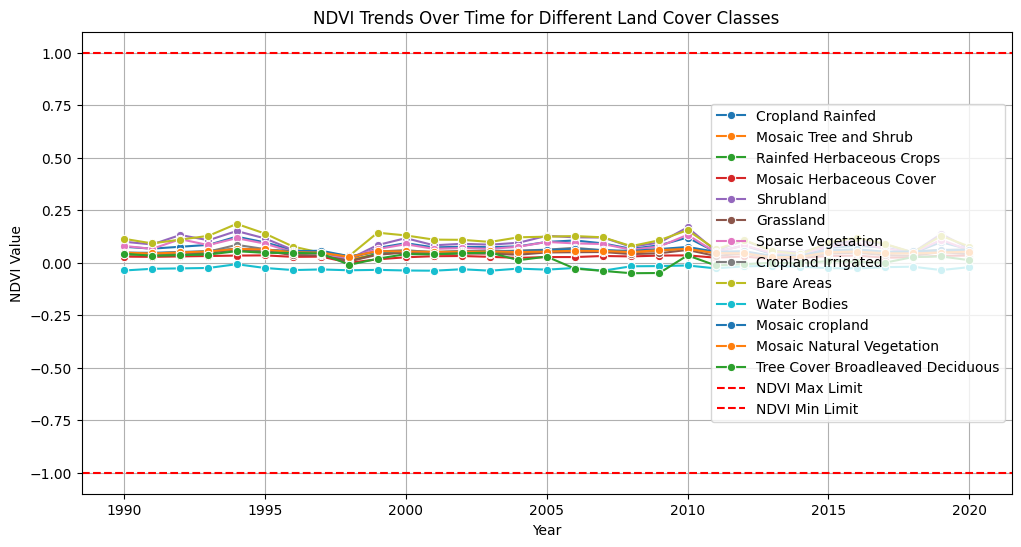

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(12, 6))

# Plot NDVI trends over time for each land cover class
for col in df.columns[1:]:  # Skip the 'Year' column
    sns.lineplot(data=df, x="Year", y=col, marker="o", label=col)

# Add reference lines for valid NDVI range (-1 to 1)
plt.axhline(y=1, color='r', linestyle='--', label="NDVI Max Limit")
plt.axhline(y=-1, color='r', linestyle='--', label="NDVI Min Limit")

# Set labels and title
plt.xlabel("Year")
plt.ylabel("NDVI Value")
plt.title("NDVI Trends Over Time for Different Land Cover Classes")
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()


Section 3: Mann-Kendall Test and Sen’s Slope Functions

In [31]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


Section 4: Perform Analysis

In [32]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Cropland Rainfed,No Trend,0.563083,-0.578268,-0.00025
Mosaic Tree and Shrub,No Trend,0.385332,0.868114,0.000143
Rainfed Herbaceous Crops,Increasing,0.026857,2.213588,0.000429
Mosaic Herbaceous Cover,No Trend,0.758615,0.3073,0.0
Shrubland,No Trend,0.475193,-0.714056,-0.0006
Grassland,No Trend,0.37606,-0.885179,-0.000167
Sparse Vegetation,No Trend,0.586159,-0.54441,-0.000286
Cropland Irrigated,No Trend,0.384734,0.869206,0.000225
Bare Areas,No Trend,0.106132,-1.615827,-0.0012
Water Bodies,No Trend,0.082272,1.737655,0.000364


In [33]:

# Create a DataFrame from the data dictionary
df = pd.DataFrame(data)

# Display the DataFrame
print("NDVI Class Trends analysis:")
df.head()

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, df['Year'])

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
         "Z-Statistic": z_stat,
         'Intercept': intercept,
         "Sen's Slope": sen_slope,
         #'Slope': slope,
         'Lower Slope': lower_slope,
         'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results in the output
print("\nStatistical Analysis Results for class NDVI Trends:")
results_df

NDVI Class Trends analysis:

Statistical Analysis Results for class NDVI Trends:


,Mann-Kendall Trend,P-Value,Z-Statistic,Intercept,Sen's Slope,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.563083,-0.578268,0.57725,-0.00025,-0.001235,0.000759
Mosaic Tree and Shrub,no trend,0.385332,0.868114,-0.236429,0.000143,-0.0002,0.0005
Rainfed Herbaceous Crops,increasing,0.026857,2.213588,-0.809286,0.000429,0.00006,0.00075
Mosaic Herbaceous Cover,no trend,0.758615,0.3073,0.029,0.0,-0.000182,0.00024
Shrubland,no trend,0.475193,-0.714056,1.293,-0.0006,-0.002067,0.001063
Grassland,no trend,0.37606,-0.885179,0.377167,-0.000167,-0.0006,0.000269
Sparse Vegetation,no trend,0.586159,-0.54441,0.648857,-0.000286,-0.001478,0.0008
Cropland Irrigated,no trend,0.384734,0.869206,-0.398125,0.000225,-0.0002,0.000643
Bare Areas,no trend,0.106132,-1.615827,2.515,-0.0012,-0.002615,0.000412
Water Bodies,no trend,0.082272,1.737655,-0.756091,0.000364,0.0,0.0007


*** Statistical Analysis Results for class NDVI Trends with 1990 as starting point***

In [34]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from scipy.stats import theilslopes

# Create a DataFrame from the provided data dictionary
df = pd.DataFrame(data)

# Ensure the Year column is treated as numeric
df["Year"] = pd.to_numeric(df["Year"])

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        "Sen's Slope": slope,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results for review
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Updated Statistical Analysis of NDVI Trends", dataframe=results_df)


Updated Statistical Analysis of NDVI Trends


Loading ITables v2.5.2 from the internet... (need help?)


In [35]:
# Display the analysis results in the output
print("\nUpdated NDVI Winter Trends Statistical Analysis:")
results_df


Updated NDVI Winter Trends Statistical Analysis:


,Mann-Kendall Trend,P-Value,Z-Statistic,Adjusted Intercept,Sen's Slope,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.563083,-0.578268,0.07725,-0.00025,-0.001235,0.000759
Mosaic Tree and Shrub,no trend,0.385332,0.868114,0.048143,0.000143,-0.0002,0.0005
Rainfed Herbaceous Crops,increasing,0.026857,2.213588,0.042,0.000429,0.00006,0.00075
Mosaic Herbaceous Cover,no trend,0.758615,0.3073,0.029,0.0,-0.000182,0.00024
Shrubland,no trend,0.475193,-0.714056,0.1,-0.0006,-0.002067,0.001063
Grassland,no trend,0.37606,-0.885179,0.045833,-0.000167,-0.0006,0.000269
Sparse Vegetation,no trend,0.586159,-0.54441,0.08,-0.000286,-0.001478,0.0008
Cropland Irrigated,no trend,0.384734,0.869206,0.050075,0.000225,-0.0002,0.000643
Bare Areas,no trend,0.106132,-1.615827,0.1234,-0.0012,-0.002615,0.000412
Water Bodies,no trend,0.082272,1.737655,-0.033091,0.000364,0.0,0.0007


**Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class.**

In [36]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results for review
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Updated NDVI Trend Analysis with Standard Deviations", dataframe=results_df)

# Display the analysis results in the output
print("\nUpdated NDVI Winter Trend Analysis with Standard Deviations:")
results_df


Updated NDVI Winter Trend Analysis with Standard Deviations:


,Mann-Kendall Trend,P-Value,P-Value Std,Z-Statistic,Adjusted Intercept,Intercept Std,Sen's Slope,Sen Slope Std,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.563083,0.0,-0.578268,0.07725,0.023138,-0.00025,0.000997,-0.001235,0.000759
Mosaic Tree and Shrub,no trend,0.385332,0.0,0.868114,0.048143,0.009884,0.000143,0.00035,-0.0002,0.0005
Rainfed Herbaceous Crops,increasing,0.026857,0.0,2.213588,0.042,0.010949,0.000429,0.000345,0.00006,0.00075
Mosaic Herbaceous Cover,no trend,0.758615,0.0,0.3073,0.029,0.006943,0.0,0.000211,-0.000182,0.00024
Shrubland,no trend,0.475193,0.0,-0.714056,0.1,0.032882,-0.0006,0.001565,-0.002067,0.001063
Grassland,no trend,0.37606,0.0,-0.885179,0.045833,0.01078,-0.000167,0.000435,-0.0006,0.000269
Sparse Vegetation,no trend,0.586159,0.0,-0.54441,0.08,0.024155,-0.000286,0.001139,-0.001478,0.0008
Cropland Irrigated,no trend,0.384734,0.0,0.869206,0.050075,0.012542,0.000225,0.000421,-0.0002,0.000643
Bare Areas,no trend,0.106132,0.0,-1.615827,0.1234,0.033557,-0.0012,0.001514,-0.002615,0.000412
Water Bodies,no trend,0.082272,0.0,1.737655,-0.033091,0.007892,0.000364,0.00035,0.0,0.0007


***Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class and eport as CSV to file**


In [37]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results
print(results_df)

# Save results as a CSV file for review
results_df.to_csv("Updated_NDVI_Winter_Trend_Analysis.csv", index=True)


                                 Mann-Kendall Trend   P-Value P-Value Std  \
Cropland Rainfed                           no trend  0.563083         0.0   
Mosaic Tree and Shrub                      no trend  0.385332         0.0   
Rainfed Herbaceous Crops                 increasing  0.026857         0.0   
Mosaic Herbaceous Cover                    no trend  0.758615         0.0   
Shrubland                                  no trend  0.475193         0.0   
Grassland                                  no trend   0.37606         0.0   
Sparse Vegetation                          no trend  0.586159         0.0   
Cropland Irrigated                         no trend  0.384734         0.0   
Bare Areas                                 no trend  0.106132         0.0   
Water Bodies                               no trend  0.082272         0.0   
Mosaic cropland                            no trend  0.194637         0.0   
Mosaic Natural Vegetation                  no trend  0.339659         0.0   

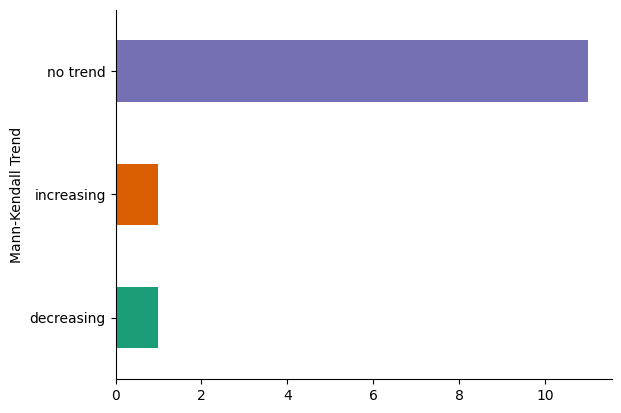

In [38]:
# @title Mann-Kendall Trend

from matplotlib import pyplot as plt
import seaborn as sns
results_df.groupby('Mann-Kendall Trend').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

Section 5: Visualization (Optional)

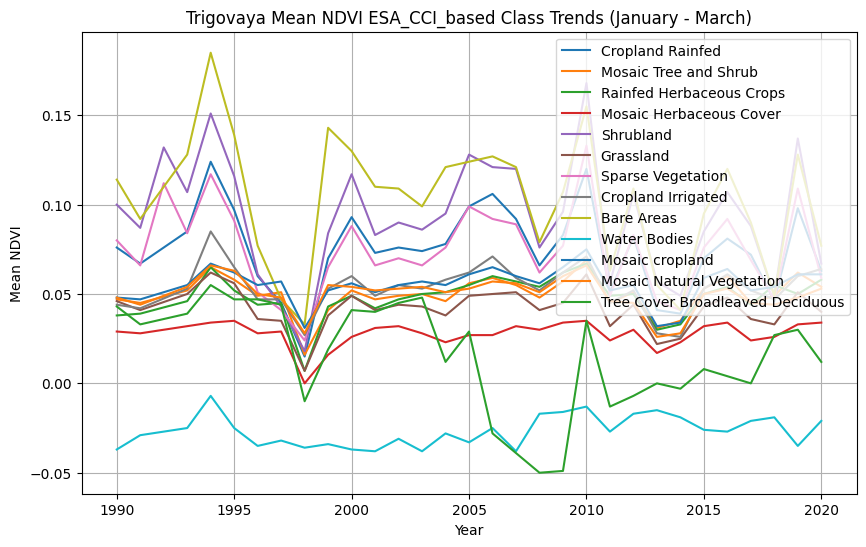

In [39]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("Trigovaya Mean NDVI ESA_CCI_based Class Trends (January - March)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.legend()
plt.grid()
plt.show()

## Analysis for significant class Winter trends

In [40]:
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],

 "Rainfed Herbaceous Crops": [	0.038,	0.039,	0.0425,	0.046,	0.065,	0.052,	0.044,	0.045,	0.007,	0.043,	0.049,
                              0.042,	0.047,	0.05,	0.051,	0.055,	0.06,	0.057,	0.054,	0.062,	0.067,	0.049,	0.05,
                               0.03,	0.033,	0.05,	0.054,	0.044,	0.055,	0.05,	0.058],
"Tree Cover Broadleaved Deciduous": [	0.043,	0.033,	0.036,	0.039,	0.055,	0.047,	0.047,	0.044,	-0.01,	0.019,
                                     0.041,	0.04,	0.045,	0.048,	0.012,	0.029,	-0.028,	-0.039,	-0.05,	-0.049,	0.035,
                                      -0.013,	-0.007,	0,	-0.003,	0.008,	0.004,	0,	0.027,	0.03,	0.012],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Rainfed Herbaceous Crops,Tree Cover Broadleaved Deciduous
0,1990,0.0380,0.043
1,1991,0.0390,0.033
2,1992,0.0425,0.036
3,1993,0.0460,0.039
4,1994,0.0650,0.055


In [41]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


In [42]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Rainfed Herbaceous Crops,Increasing,0.026857,2.213588,0.000429
Tree Cover Broadleaved Deciduous,Decreasing,0.012435,-2.499557,-0.001391


In [43]:

# Create a DataFrame from the data dictionary
df = pd.DataFrame(data)

# Display the DataFrame
print("NDVI Class Trends analysis:")
df.head()

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, df['Year'])

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
         "Z-Statistic": z_stat,
         'Intercept': intercept,
         "Sen's Slope": sen_slope,
         #'Slope': slope,
         'Lower Slope': lower_slope,
         'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results in the output
print("\nStatistical Analysis Results for class NDVI Trends:")
results_df

NDVI Class Trends analysis:

Statistical Analysis Results for class NDVI Trends:


,Mann-Kendall Trend,P-Value,Z-Statistic,Intercept,Sen's Slope,Lower Slope,Upper Slope
Rainfed Herbaceous Crops,increasing,0.026857,2.213588,-0.809286,0.000429,0.00006,0.00075
Tree Cover Broadleaved Deciduous,decreasing,0.012435,-2.499557,2.816565,-0.001391,-0.0023,-0.000346


** **Starting with 1990 as base year** ** Right approach as it affects intercept values

In [44]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results for review
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Updated NDVI Trend Analysis with Standard Deviations", dataframe=results_df)

# Display the analysis results in the output
print("\nUpdated NDVI Winter Significant Trend Analysis with Standard Deviations:")
results_df


Updated NDVI Winter Significant Trend Analysis with Standard Deviations:


,Mann-Kendall Trend,P-Value,P-Value Std,Z-Statistic,Adjusted Intercept,Intercept Std,Sen's Slope,Sen Slope Std,Lower Slope,Upper Slope
Rainfed Herbaceous Crops,increasing,0.026857,0.0,2.213588,0.042,0.010949,0.000429,0.000345,0.00006,0.00075
Tree Cover Broadleaved Deciduous,decreasing,0.012435,0.0,-2.499557,0.042783,0.025867,-0.001391,0.000977,-0.0023,-0.000346


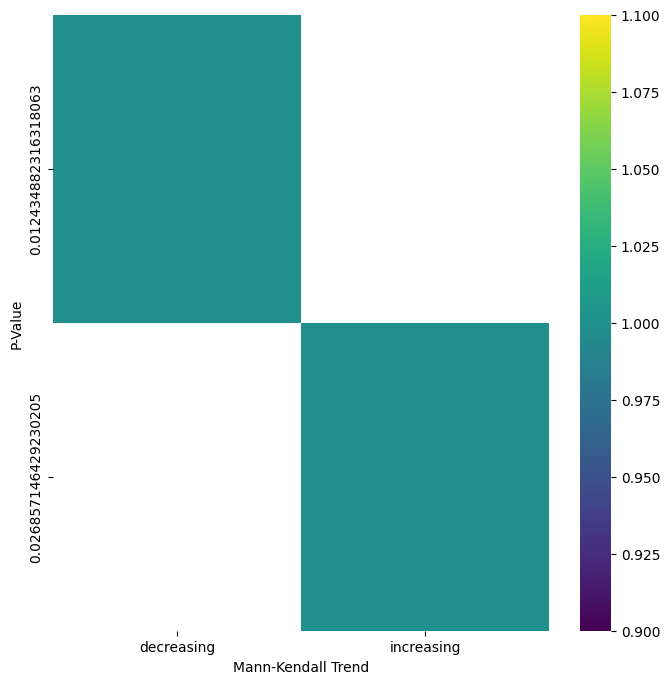

In [45]:
# @title Mann-Kendall Trend vs P-Value

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['P-Value'].value_counts()
    for x_label, grp in results_df.groupby('Mann-Kendall Trend')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Mann-Kendall Trend')
_ = plt.ylabel('P-Value')

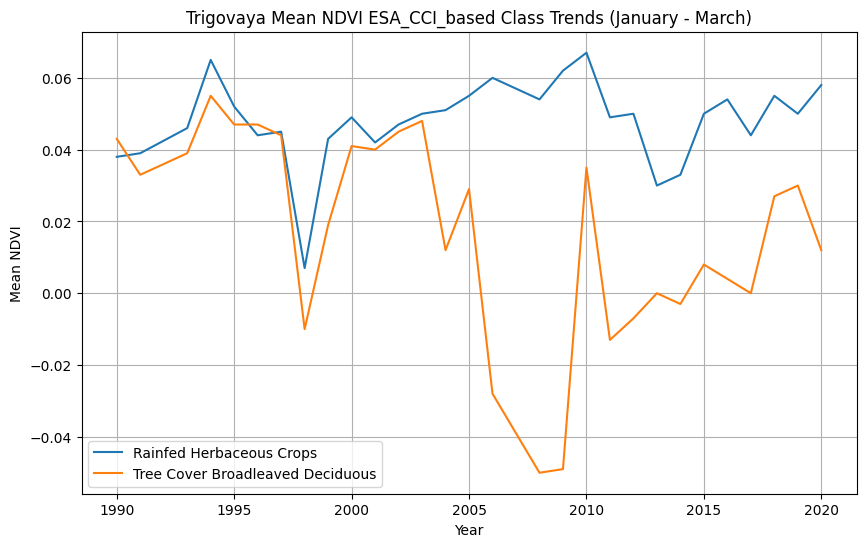

In [46]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("Trigovaya Mean NDVI ESA_CCI_based Class Trends (January - March)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.legend()
plt.grid()
plt.show()


# **SUMMER**

Section 2: Data Initialization

In [47]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau

# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],

"Cropland Rainfed": [0.107,	0.112,	0.113,	0.096,	0.099,	0.107,	0.099,	0.089,	0.091,	0.093,	0.087,	0.083,	0.078,	0.076,	0.085,	0.085,	0.094,	0.088,	0.072,	0.09,	0.091,	0.08,	0.096,	0.089,	0.093,	0.077,	0.101,	0.121,	0.107,	0.126,	0.138],
"Mosaic Tree and Shrub": [	0.121,	0.118,	0.12,	0.127,	0.123,	0.136,	0.121,	0.11,	0.116,	0.117,	0.099,	0.094,	0.09,	0.086,	0.094,	0.091,	0.106,	0.097,	0.082,	0.099,	0.098,	0.092,	0.107,	0.094,	0.096,	0.084,	0.094,	0.111,	0.092,	0.098,	0.1],
"Rainfed Herbaceous Crops": [0.146,	0.139,	0.139,	0.141,	0.139,	0.157,	0.146,	0.143,	0.144,	0.146,	0.138,	0.129,	0.135,	0.132,	0.15,	0.146,	0.155,	0.147,	0.118,	0.154,	0.147,	0.134,	0.16,	0.147,	0.146,	0.125,	0.155,	0.161,	0.142,	0.148,	0.16],
"Mosaic Herbaceous Cover": [0.134,	0.128,	0.125,	0.125,	0.125,	0.143,	0.125,	0.121,	0.127,	0.134,	0.116,	0.101,	0.12,	0.117,	0.124,	0.116,	0.129,	0.107,	0.098,	0.125,	0.13,	0.111,	0.12,	0.109,	0.101,	0.091,	0.118,	0.133,	0.129,	0.127,	0.139],
"Shrubland": [0.07,	0.072,	0.072,	0.058,	0.063,	0.068,	0.062,	0.051,	0.053,	0.057,	0.052,	0.051,	0.043,	0.04,	0.049,	0.058,	0.059,	0.057,	0.046,	0.056,	0.058,	0.043,	0.058,	0.054,	0.056,	0.045,	0.06,	0.079,	0.07,	0.086,	0.092],
"Grassland": [0.091,	0.091,	0.093,	0.09,	0.09,	0.105,	0.094,	0.09,	0.091,	0.094,	0.088,	0.083,	0.08,	0.076,	0.084,	0.081,	0.09,	0.085,	0.074,	0.088,	0.087,	0.076,	0.087,	0.082,	0.081,	0.073,	0.084,	0.093,	0.082,	0.086,	0.092],
"Sparse Vegetation": [0.072,	0.074,	0.075,	0.068,	0.069,	0.079,	0.07,	0.06,	0.063,	0.068,	0.059,	0.058,	0.054,	0.051,	0.059,	0.065,	0.069,	0.064,	0.054,	0.066,	0.065,	0.053,	0.067,	0.061,	0.064,	0.055,	0.072,	0.083,	0.07,	0.079,	0.08],
"Cropland Irrigated": [0.173,	0.172,	0.17,	0.163,	0.163,	0.171,	0.162,	0.154,	0.162,	0.16,	0.154,	0.151,	0.155,	0.148,	0.166,	0.158,	0.168,	0.163,	0.142,	0.169,	0.164,	0.153,	0.173,	0.168,	0.167,	0.154,	0.172,	0.176,	0.164,	0.169,	0.181],
"Bare Areas": [0.063,	0.062,	0.065,	0.054,	0.059,	0.067,	0.06,	0.053,	0.055,	0.054,	0.05,	0.048,	0.043,	0.038,	0.047,	0.051,	0.054,	0.052,	0.043,	0.054,	0.053,	0.042,	0.055,	0.049,	0.051,	0.045,	0.048,	0.06,	0.047,	0.057,	0.061],
"Water Bodies": [0.041,	0.038,	0.035,	0.036,	0.028,	0.039,	0.03,	0.029,	0.022,	0.019,	0.014,	0.017,	0.009,	0.024,	0.019,	0.017,	0.023,	0.021,	0.021,	0.031,	0.031,	0.033,	0.036,	0.033,	0.029,	0.027,	0.035,	0.038,	0.038,	0.034,	0.041],
"Mosaic cropland": [0.143,	0.136,	0.151,	0.154,	0.15,	0.168,	0.155,	0.148,	0.156,	0.155,	0.136,	0.13,	0.126,	0.123,	0.135,	0.135,	0.142,	0.136,	0.115,	0.14,	0.141,	0.125,	0.15,	0.14,	0.144,	0.13,	0.14,	0.156,	0.133,	0.139,	0.15],
"Mosaic Natural Vegetation": [0.153,	0.147,	0.162,	0.162,	0.159,	0.177,	0.161,	0.159,	0.17,	0.168,	0.156,	0.146,	0.142,	0.135,	0.148,	0.148,	0.153,	0.149,	0.129,	0.157,	0.156,	0.151,	0.175,	0.167,	0.17,	0.154,	0.168,	0.176,	0.158,	0.161,	0.175],
"Tree Cover Broadleaved Deciduous": [0.155,	0.145,	0.138,	0.133,	0.166,	0.197,	0.174,	0.195,	0.204,	0.212,	0.238,	0.199,	0.215,	0.13,	0.147,	0.13,	0.101,	0.044,	0.014,	0.017,	-0.009,	-0.043,	-0.001,	0.023,	0.023,	0.02,	0.041,	0.037,	0.042,	0.043,	0.055],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Cropland Rainfed,Mosaic Tree and Shrub,Rainfed Herbaceous Crops,Mosaic Herbaceous Cover,Shrubland,Grassland,Sparse Vegetation,Cropland Irrigated,Bare Areas,Water Bodies,Mosaic cropland,Mosaic Natural Vegetation,Tree Cover Broadleaved Deciduous
0,1990,0.107,0.121,0.146,0.134,0.070,0.091,0.072,0.173,0.063,0.041,0.143,0.153,0.155
1,1991,0.112,0.118,0.139,0.128,0.072,0.091,0.074,0.172,0.062,0.038,0.136,0.147,0.145
2,1992,0.113,0.120,0.139,0.125,0.072,0.093,0.075,0.170,0.065,0.035,0.151,0.162,0.138
3,1993,0.096,0.127,0.141,0.125,0.058,0.090,0.068,0.163,0.054,0.036,0.154,0.162,0.133
4,1994,0.099,0.123,0.139,0.125,0.063,0.090,0.069,0.163,0.059,0.028,0.150,0.159,0.166


Section 3: Mann-Kendall Test and Sen’s Slope Functions

In [48]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


Section 4: Perform Analysis

In [49]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Cropland Rainfed,No Trend,0.905163,-0.119141,0.0
Mosaic Tree and Shrub,Decreasing,0.00173,-3.133078,-0.001
Rainfed Herbaceous Crops,No Trend,0.07054,1.808424,0.000321
Mosaic Herbaceous Cover,No Trend,0.194983,-1.295978,-0.000333
Shrubland,No Trend,0.918602,-0.102195,0.0
Grassland,Decreasing,0.009104,-2.608123,-0.000333
Sparse Vegetation,No Trend,0.878267,-0.153167,-0.000053
Cropland Irrigated,No Trend,0.474468,0.715228,0.000118
Bare Areas,Decreasing,0.042645,-2.027166,-0.000333
Water Bodies,No Trend,0.340314,0.953546,0.000222


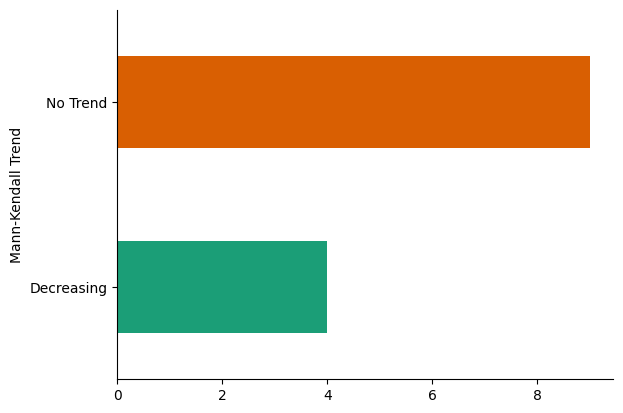

In [50]:
# @title Mann-Kendall Trend

from matplotlib import pyplot as plt
import seaborn as sns
results_df.groupby('Mann-Kendall Trend').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [51]:

# Create a DataFrame from the data dictionary
df = pd.DataFrame(data)

# Display the DataFrame
print("NDVI Class Trends analysis:")
df.head()

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, df['Year'])

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
         "Z-Statistic": z_stat,
         'Intercept': intercept,
         "Sen's Slope": sen_slope,
         #'Slope': slope,
         'Lower Slope': lower_slope,
         'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results in the output
print("\nStatistical Analysis Results for class NDVI Trends:")
results_df

NDVI Class Trends analysis:

Statistical Analysis Results for class NDVI Trends:


,Mann-Kendall Trend,P-Value,Z-Statistic,Intercept,Sen's Slope,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.905163,-0.119141,0.093,0.0,-0.000762,0.000792
Mosaic Tree and Shrub,decreasing,0.00173,-3.133078,2.104,-0.001,-0.001435,-0.000455
Rainfed Herbaceous Crops,no trend,0.07054,1.808424,-0.498464,0.000321,0.0,0.000724
Mosaic Herbaceous Cover,no trend,0.194983,-1.295978,0.793333,-0.000333,-0.0009,0.00016
Shrubland,no trend,0.918602,-0.102195,0.058,0.0,-0.000545,0.000519
Grassland,decreasing,0.009104,-2.608123,0.755333,-0.000333,-0.000571,-0.0001
Sparse Vegetation,no trend,0.878267,-0.153167,0.171526,-0.000053,-0.000471,0.000407
Cropland Irrigated,no trend,0.474468,0.715228,-0.071882,0.000118,-0.000267,0.000526
Bare Areas,decreasing,0.042645,-2.027166,0.721333,-0.000333,-0.000609,0.0
Water Bodies,no trend,0.340314,0.953546,-0.415556,0.000222,-0.000222,0.00075


*** Statistical Analysis Results for class NDVI Trends with 1990 as starting point***

In [52]:
import pandas as pd
import numpy as np
import pymannkendall as mk
from scipy.stats import theilslopes

# Create a DataFrame from the provided data dictionary
df = pd.DataFrame(data)

# Ensure the Year column is treated as numeric
df["Year"] = pd.to_numeric(df["Year"])

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        "Sen's Slope": slope,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results for review
import ace_tools_open as tools; tools.display_dataframe_to_user(name="Updated Statistical Analysis of NDVI Trends", dataframe=results_df)


Updated Statistical Analysis of NDVI Trends


Loading ITables v2.5.2 from the internet... (need help?)


In [53]:
# Display the analysis results in the output
print("\nUpdated NDVI Summer Trends Statistical Analysis:")
results_df


Updated NDVI Summer Trends Statistical Analysis:


,Mann-Kendall Trend,P-Value,Z-Statistic,Adjusted Intercept,Sen's Slope,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.905163,-0.119141,0.093,0.0,-0.000762,0.000792
Mosaic Tree and Shrub,decreasing,0.00173,-3.133078,0.12,-0.001,-0.001435,-0.000455
Rainfed Herbaceous Crops,no trend,0.07054,1.808424,0.140571,0.000321,0.0,0.000724
Mosaic Herbaceous Cover,no trend,0.194983,-1.295978,0.126667,-0.000333,-0.0009,0.00016
Shrubland,no trend,0.918602,-0.102195,0.058,0.0,-0.000545,0.000519
Grassland,decreasing,0.009104,-2.608123,0.091333,-0.000333,-0.000571,-0.0001
Sparse Vegetation,no trend,0.878267,-0.153167,0.067,-0.000053,-0.000471,0.000407
Cropland Irrigated,no trend,0.474468,0.715228,0.162529,0.000118,-0.000267,0.000526
Bare Areas,decreasing,0.042645,-2.027166,0.057667,-0.000333,-0.000609,0.0
Water Bodies,no trend,0.340314,0.953546,0.027111,0.000222,-0.000222,0.00075


**Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class.**

In [54]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results for review
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Updated NDVI Trend Analysis with Standard Deviations", dataframe=results_df)

# Display the analysis results in the output
print("\nUpdated NDVI Summer Trend Analysis with Standard Deviations:")
results_df


Updated NDVI Summer Trend Analysis with Standard Deviations:


,Mann-Kendall Trend,P-Value,P-Value Std,Z-Statistic,Adjusted Intercept,Intercept Std,Sen's Slope,Sen Slope Std,Lower Slope,Upper Slope
Cropland Rainfed,no trend,0.905163,0.0,-0.119141,0.093,0.014934,0.0,0.000777,-0.000762,0.000792
Mosaic Tree and Shrub,decreasing,0.00173,0.0,-3.133078,0.12,0.010288,-0.001,0.00049,-0.001435,-0.000455
Rainfed Herbaceous Crops,no trend,0.07054,0.0,1.808424,0.140571,0.009749,0.000321,0.000362,0.0,0.000724
Mosaic Herbaceous Cover,no trend,0.194983,0.0,-1.295978,0.126667,0.011634,-0.000333,0.00053,-0.0009,0.00016
Shrubland,no trend,0.918602,0.0,-0.102195,0.058,0.01206,0.0,0.000532,-0.000545,0.000519
Grassland,decreasing,0.009104,0.0,-2.608123,0.091333,0.006029,-0.000333,0.000236,-0.000571,-0.0001
Sparse Vegetation,no trend,0.878267,0.0,-0.153167,0.067,0.008348,-0.000053,0.000439,-0.000471,0.000407
Cropland Irrigated,no trend,0.474468,0.0,0.715228,0.162529,0.008627,0.000118,0.000396,-0.000267,0.000526
Bare Areas,decreasing,0.042645,0.0,-2.027166,0.057667,0.006506,-0.000333,0.000304,-0.000609,0.0
Water Bodies,no trend,0.340314,0.0,0.953546,0.027111,0.008403,0.000222,0.000486,-0.000222,0.00075


***Sen’s Slope, P-value, Intercept, and their Standard Deviations for each land cover class and eport as CSV to file**


In [55]:
import numpy as np
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:  # Skip the 'Year' column
    # Extract time series data for the land cover class
    time_series = df[col].values
    years = df["Year"].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, years)

    # Adjust the intercept using a reference year (1990) instead of year 0
    adjusted_intercept = np.median(time_series - slope * (years - 1990))

    # Compute standard deviation for Sen’s Slope
    slope_std = np.std([lower_slope, upper_slope])

    # Compute standard deviation for Intercept
    intercept_std = np.std(time_series - slope * years)

    # Compute standard deviation for P-Value (although not typically reported, useful for robustness check)
    p_value_std = np.std([mk_result.p])

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
        'P-Value Std': p_value_std,
        'Z-Statistic': mk_result.z,
        'Adjusted Intercept': adjusted_intercept,
        'Intercept Std': intercept_std,
        "Sen's Slope": slope,
        'Sen Slope Std': slope_std,
        'Lower Slope': lower_slope,
        'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the updated analysis results
print(results_df)

# Save results as a CSV file for review
results_df.to_csv("Updated_NDVI_Summer_Trend_Analysis.csv", index=True)


                                 Mann-Kendall Trend   P-Value P-Value Std  \
Cropland Rainfed                           no trend  0.905163         0.0   
Mosaic Tree and Shrub                    decreasing   0.00173         0.0   
Rainfed Herbaceous Crops                   no trend   0.07054         0.0   
Mosaic Herbaceous Cover                    no trend  0.194983         0.0   
Shrubland                                  no trend  0.918602         0.0   
Grassland                                decreasing  0.009104         0.0   
Sparse Vegetation                          no trend  0.878267         0.0   
Cropland Irrigated                         no trend  0.474468         0.0   
Bare Areas                               decreasing  0.042645         0.0   
Water Bodies                               no trend  0.340314         0.0   
Mosaic cropland                            no trend  0.226521         0.0   
Mosaic Natural Vegetation                  no trend  0.283644         0.0   

Section 5: Visualization (Optional)

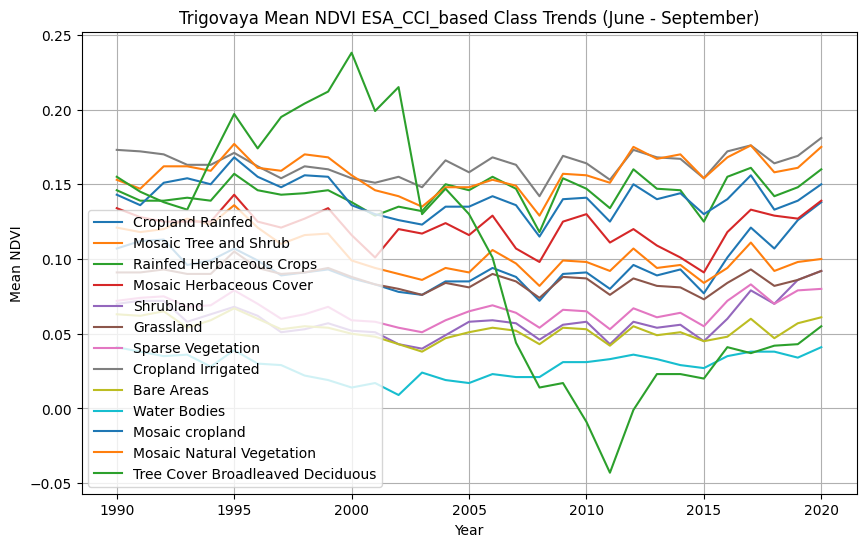

In [56]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("Trigovaya Mean NDVI ESA_CCI_based Class Trends (June - September)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.legend()
plt.grid()
plt.show()


## Analysis for significant class trends in Summer Season


In [57]:
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
             2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],

            "Mosaic Tree and Shrub": [	0.121,	0.118,	0.12,	0.127,	0.123,	0.136,	0.121,	0.11,	0.116,	0.117,	0.099,	0.094,
                                      0.09,	0.086,	0.094,	0.091,	0.106,	0.097,	0.082,	0.099,	0.098,	0.092,	0.107,	0.094,
                                       0.096,	0.084,	0.094,	0.111,	0.092,	0.098,	0.1],
            "Grassland": [0.091,	0.091,	0.093,	0.09,	0.09,	0.105,	0.094,	0.09,	0.091,	0.094,	0.088,	0.083,	0.08,	0.076,	0.084,
                          0.081,	0.09,	0.085,	0.074,	0.088,	0.087,	0.076,	0.087,	0.082,	0.081,	0.073,	0.084,	0.093,	0.082,	0.086,	0.092],
            "Bare Areas": [0.063,	0.062,	0.065,	0.054,	0.059,	0.067,	0.06,	0.053,	0.055,	0.054,	0.05,	0.048,	0.043,	0.038,	0.047,	0.051,
                           0.054,	0.052,	0.043,	0.054,	0.053,	0.042,	0.055,	0.049,	0.051,	0.045,	0.048,	0.06,	0.047,	0.057,	0.061],
            "Tree Cover Broadleaved Deciduous": [0.155,	0.145,	0.138,	0.133,	0.166,	0.197,	0.174,	0.195,	0.204,	0.212,	0.238,	0.199,	0.215,
                                                 0.13,	0.147,	0.13,	0.101,	0.044,	0.014,	0.017,	-0.009,	-0.043,	-0.001,	0.023,	0.023,	0.02,	0.041,
                                                 0.037,	0.042,	0.043,	0.055],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Mosaic Tree and Shrub,Grassland,Bare Areas,Tree Cover Broadleaved Deciduous
0,1990,0.121,0.091,0.063,0.155
1,1991,0.118,0.091,0.062,0.145
2,1992,0.120,0.093,0.065,0.138
3,1993,0.127,0.090,0.054,0.133
4,1994,0.123,0.090,0.059,0.166


In [58]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


In [59]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Mosaic Tree and Shrub,Decreasing,0.00173,-3.133078,-0.001
Grassland,Decreasing,0.009104,-2.608123,-0.000333
Bare Areas,Decreasing,0.042645,-2.027166,-0.000333
Tree Cover Broadleaved Deciduous,Decreasing,0.001566,-3.162247,-0.006357


In [60]:

# Create a DataFrame from the data dictionary
df = pd.DataFrame(data)

# Display the DataFrame
print("NDVI Class Trends analysis:")
df.head()

# Initialize dictionary to store analysis results for each class
results = {}

# Loop through each land cover class column (skip the 'Year' column)
for col in df.columns[1:]:
    # Extract time series data for the land cover class
    time_series = df[col].values

    # Mann-Kendall Trend Test for monotonic trends
    mk_result = mk.original_test(time_series)

    # Theil-Sen Slope Estimator for rate of change
    slope, intercept, lower_slope, upper_slope = theilslopes(time_series, df['Year'])

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Store results for each class in the results dictionary
    results[col] = {
        'Mann-Kendall Trend': mk_result.trend,
        'P-Value': mk_result.p,
         "Z-Statistic": z_stat,
         'Intercept': intercept,
         "Sen's Slope": sen_slope,
         #'Slope': slope,
         'Lower Slope': lower_slope,
         'Upper Slope': upper_slope
    }

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results).T

# Display the analysis results in the output
print("\nStatistical Analysis Results for class NDVI Trends:")
results_df

NDVI Class Trends analysis:

Statistical Analysis Results for class NDVI Trends:


,Mann-Kendall Trend,P-Value,Z-Statistic,Intercept,Sen's Slope,Lower Slope,Upper Slope
Mosaic Tree and Shrub,decreasing,0.00173,-3.133078,2.104,-0.001,-0.001435,-0.000455
Grassland,decreasing,0.009104,-2.608123,0.755333,-0.000333,-0.000571,-0.0001
Bare Areas,decreasing,0.042645,-2.027166,0.721333,-0.000333,-0.000609,0.0
Tree Cover Broadleaved Deciduous,decreasing,0.001566,-3.162247,12.876071,-0.006357,-0.008789,-0.00364


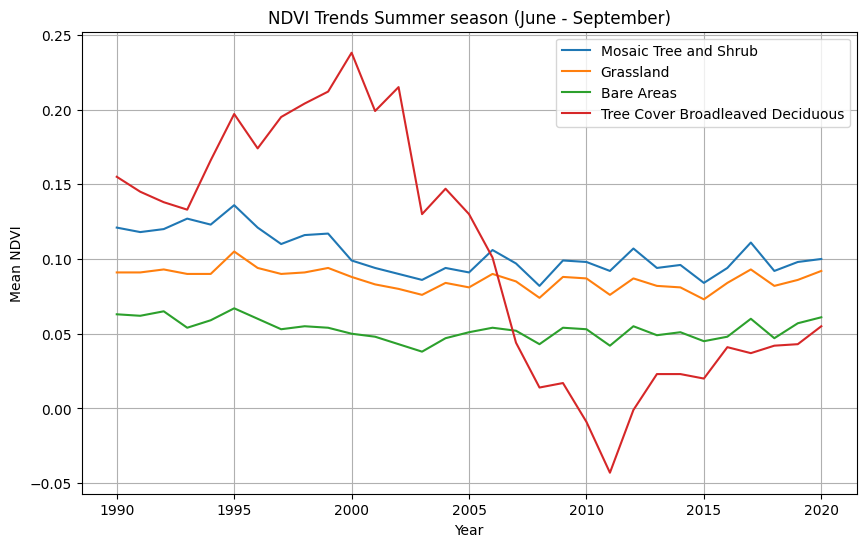

In [61]:
import matplotlib.pyplot as plt

# Plot NDVI trends for visualization
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col)

plt.title("NDVI Trends Summer season (June - September)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.legend()
plt.grid()
plt.show()


################################################################

### **Target Years (1990, 2000, 2010, 2020) from direct GEE - L5, L7, L5, L8**


Section 2: Data Initialization

In [62]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
# Define the NDVI data extracted from the document
data = {
    "Year": [1990, 2000, 2010, 2020],

    "Cropland Rainfed":[0.098,0.066,0.085,0.137],
    "Mosaic Tree and Shrub": [0.113,0.068,0.092,0.114],
    "Rainfed Herbaceous Crops":[0.133,0.078,0.133,0.164],
    "Mosaic Herbaceous Cover":[0.119,0.055,0.101,0.142],
    "Shrubland":[0.067,0.057,0.061,0.096],
    "Grassland":[0.084,0.052,0.077,0.1],
    "Sparse Vegetation":[0.068,0.056,0.065,0.09],
    "Cropland Irrigated":[0.149,0.084,0.135,0.18],
    "Bare Areas":[0.062,0.061,0.06,0.078],
    "Water Bodies":[0.03,-0.008,0.027,0.039],
    "Mosaic cropland":[0.134,0.083,0.127,0.159],
    "Mosaic Natural Vegetation":[0.14,0.078,0.129,0.177],
    "Tree Cover Broadleaved Deciduous":[0.139,0.131,0.014,0.061],

    # Add more classes as needed
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
df.head()  # Display the first few rows


,Year,Cropland Rainfed,Mosaic Tree and Shrub,Rainfed Herbaceous Crops,Mosaic Herbaceous Cover,Shrubland,Grassland,Sparse Vegetation,Cropland Irrigated,Bare Areas,Water Bodies,Mosaic cropland,Mosaic Natural Vegetation,Tree Cover Broadleaved Deciduous
0,1990,0.098,0.113,0.133,0.119,0.067,0.084,0.068,0.149,0.062,0.030,0.134,0.140,0.139
1,2000,0.066,0.068,0.078,0.055,0.057,0.052,0.056,0.084,0.061,-0.008,0.083,0.078,0.131
2,2010,0.085,0.092,0.133,0.101,0.061,0.077,0.065,0.135,0.060,0.027,0.127,0.129,0.014
3,2020,0.137,0.114,0.164,0.142,0.096,0.100,0.090,0.180,0.078,0.039,0.159,0.177,0.061


Section 3: Mann-Kendall Test and Sen’s Slope Functions

In [63]:
from scipy import stats  # Add this import

def mann_kendall_test(data):
    n = len(data)
    s = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            s += np.sign(data[j] - data[i])
    unique_data, counts = np.unique(data, return_counts=True)
    tie_sum = sum(count * (count - 1) * (2 * count + 5) for count in counts if count > 1)
    var_s = (n * (n - 1) * (2 * n + 5) - tie_sum) / 18
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s == 0:
        z = 0
    else:
        z = (s + 1) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # Use the imported stats module
    trend = "Increasing" if z > 0 and p < 0.05 else "Decreasing" if z < 0 and p < 0.05 else "No Trend"
    return trend, p, z

def calculate_sens_slope(data, years):
    slopes = [(data[j] - data[i]) / (years[j] - years[i]) for i in range(len(data)) for j in range(i + 1, len(data))]
    return np.median(slopes)


Section 4: Perform Analysis

In [64]:
# Perform Mann-Kendall and Sen's Slope analysis
years = df["Year"]
results = {}
for col in df.columns[1:]:  # Skip the "Year" column
    trend, p_value, z_stat = mann_kendall_test(df[col])
    sen_slope = calculate_sens_slope(df[col], years)
    results[col] = {
        "Mann-Kendall Trend": trend,
        "p-value": p_value,
        "Z-Statistic": z_stat,
        "Sen's Slope": sen_slope
    }

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Mann-Kendall Trend,p-value,Z-Statistic,Sen's Slope
Cropland Rainfed,No Trend,0.734095,0.339683,0.0016
Mosaic Tree and Shrub,No Trend,0.734095,0.339683,0.001117
Rainfed Herbaceous Crops,No Trend,0.470101,0.722315,0.002067
Mosaic Herbaceous Cover,No Trend,0.734095,0.339683,0.002433
Shrubland,No Trend,0.734095,0.339683,0.000683
Grassland,No Trend,0.734095,0.339683,0.001417
Sparse Vegetation,No Trend,0.734095,0.339683,0.000817
Cropland Irrigated,No Trend,0.734095,0.339683,0.002767
Bare Areas,No Trend,1.0,0,0.000217
Water Bodies,No Trend,0.734095,0.339683,0.00075


## 1. Maps
Purpose: Highlight spatial variability in NDVI trends across regions and land cover types.
1. Display increasing, decreasing, and stable NDVI trends for each land cover type.
Color-coded:
Green: Increasing.
Red: Decreasing.
Yellow: Stable.
Slope Magnitude Map:

2. Use a gradient scale (e.g., blue to red) to represent the magnitude of Sen’s Slope values for NDVI trends.
Significance Map:

3. Highlight areas with statistically significant trends (e.g.,
𝑝
<
0.05
p<0.05).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio

os.chdir('/content/driver/My Drive/*File name*/')

# Load NDVI slope raster
with rasterio.open("NDVI_Slope.tif") as src:
    slope = src.read(1)

# Plot slope map
plt.imshow(slope, cmap="coolwarm", vmin=-0.005, vmax=0.005)
plt.colorbar(label="Sen's Slope (NDVI)")
plt.title("NDVI Trend Slope")
plt.show()

## 2. Time-Series Graphs
 Purpose: Show temporal changes in NDVI values for specific land cover types or regions.
Approach:
1. Plot mean NDVI values for a class over time (e.g., annual, seasonal averages).
2. Use line plots with trend lines to visualize overall patterns.


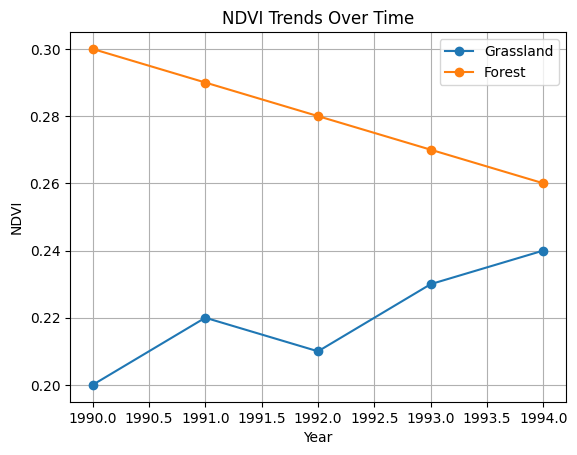

In [67]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    "Year": [1990, 1991, 1992, 1993, 1994],
    "NDVI_Grassland": [0.2, 0.22, 0.21, 0.23, 0.24],
    "NDVI_Forest": [0.3, 0.29, 0.28, 0.27, 0.26]
}
df = pd.DataFrame(data)

# Plot NDVI trends
plt.plot(df["Year"], df["NDVI_Grassland"], label="Grassland", marker='o')
plt.plot(df["Year"], df["NDVI_Forest"], label="Forest", marker='o')
plt.xlabel("Year")
plt.ylabel("NDVI")
plt.title("NDVI Trends Over Time")
plt.legend()
plt.grid(True)
plt.show()


## 3. Statistical Plots
Purpose: Visualize the distribution and significance of NDVI trends.
Types:
Boxplots:

Compare NDVI trends across land cover types.

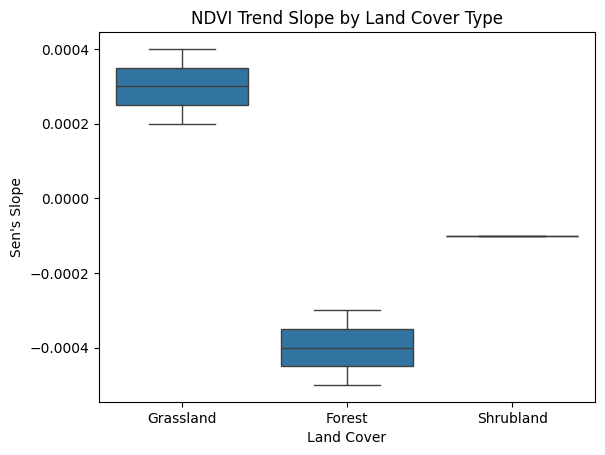

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# data
data = {
    "Land Cover": ["Grassland", "Forest", "Shrubland", "Grassland", "Forest"],
    "Sen's Slope": [0.0002, -0.0003, -0.0001, 0.0004, -0.0005]
}
sns.boxplot(x="Land Cover", y="Sen's Slope", data=pd.DataFrame(data))
plt.title("NDVI Trend Slope by Land Cover Type")
plt.show()


## 1. Line Plots for Temporal Trends
Purpose:To display NDVI changes over time for different classes or seasons.

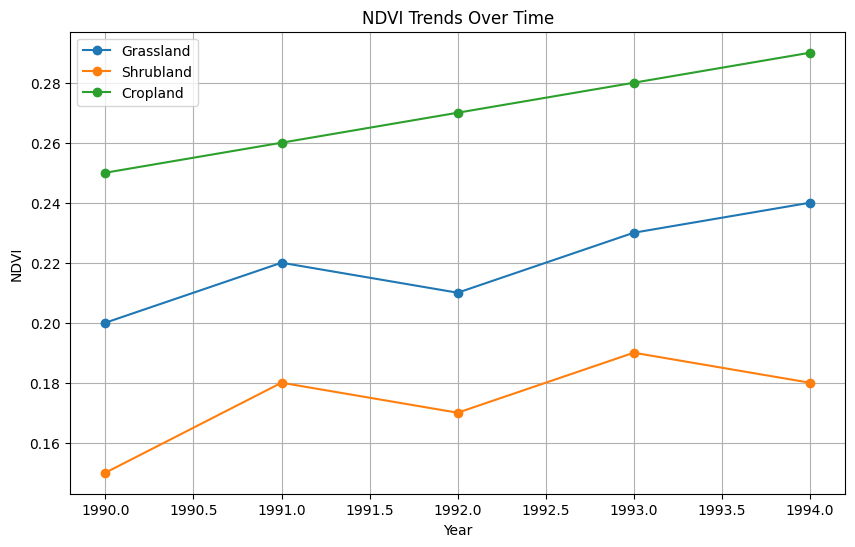

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

#  NDVI data
data = {
    "Year": [1990, 1991, 1992, 1993, 1994],
    "Grassland": [0.2, 0.22, 0.21, 0.23, 0.24],
    "Shrubland": [0.15, 0.18, 0.17, 0.19, 0.18],
    "Cropland": [0.25, 0.26, 0.27, 0.28, 0.29]
}

df = pd.DataFrame(data)

# Plot NDVI trends
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Year"], df[col], label=col, marker='o')

plt.title("NDVI Trends Over Time")
plt.xlabel("Year")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.show()


## 2. Boxplots for Variance Analysis
Purpose: To compare NDVI variance across classes or regions.

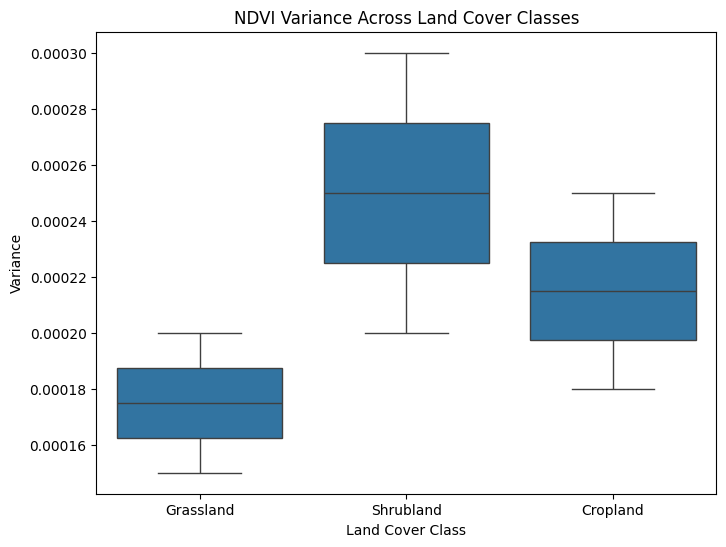

In [70]:
import seaborn as sns

#  variance data
data = {
    "Class": ["Grassland", "Shrubland", "Cropland", "Grassland", "Shrubland", "Cropland"],
    "Variance": [0.0002, 0.0003, 0.00025, 0.00015, 0.0002, 0.00018]


#"Class": ["Cropland Rainfed", "Mosaic Tree and Shrub", "Rainfed Herbaceous Crops", "Mosaic Herbaceous Cover",
#"Shrubland", "Grassland", "Sparse Vegetation", "Cropland Irrigated", "Bare Areas", "Water Bodies", "Mosaic cropland",
#"Mosaic Natural Vegetation"], #"Tree Cover Broadleaved Deciduous"
# "Variance": [0.000163,	0.000171,	0.000201,	0.000234,	0.000076,	0.000073,	0.000048,	0.000218,	0.000038,	0.000112,	0.00019,	0.000271] #0.004681
}

df = pd.DataFrame(data)

# Create a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="Class", y="Variance", data=df)
plt.title("NDVI Variance Across Land Cover Classes")
plt.xlabel("Land Cover Class")
plt.ylabel("Variance")
plt.show()


## 3. Heatmaps for Correlation
Purpose: To display correlations between NDVI trends and other factors (e.g., climatic data).

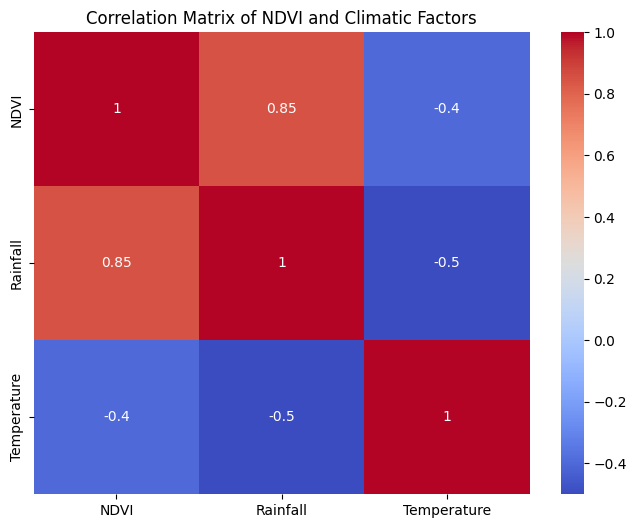

In [71]:
import numpy as np

#  correlation matrix
corr_matrix = np.array([
    [1.0, 0.85, -0.4],
    [0.85, 1.0, -0.5],
    [-0.4, -0.5, 1.0]
])

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=["NDVI", "Rainfall", "Temperature"],
            yticklabels=["NDVI", "Rainfall", "Temperature"], cmap="coolwarm")
plt.title("Correlation Matrix of NDVI and Climatic Factors")
plt.show()


## 4. Bar Charts for Class-Specific Trends
Purpose: To visualize differences in trends (e.g., Sen's Slope) across land cover classes

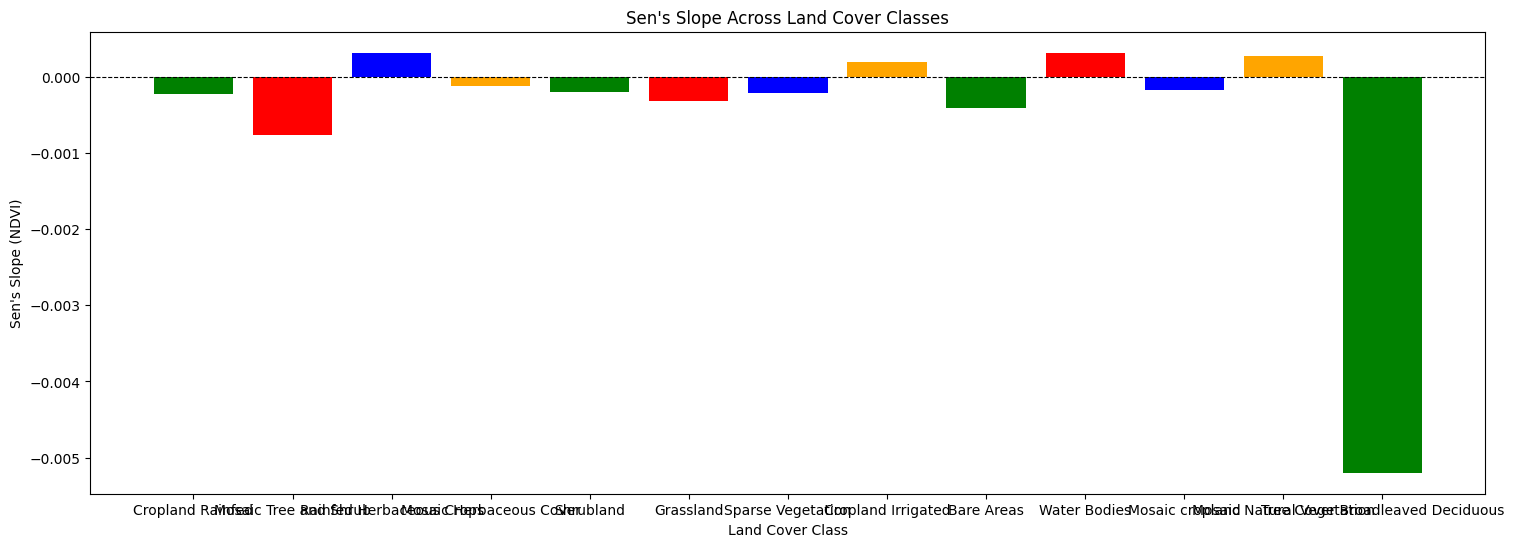

In [72]:
#  Sen's Slope data
#classes = ["Grassland", "Shrubland", "Cropland", "Deciduous Forest"]
#slope = [0.0003, -0.0002, 0.0004, -0.0005]

classes = ["Cropland Rainfed", "Mosaic Tree and Shrub", "Rainfed Herbaceous Crops", "Mosaic Herbaceous Cover",
"Shrubland", "Grassland", "Sparse Vegetation", "Cropland Irrigated", "Bare Areas", "Water Bodies", "Mosaic cropland",
"Mosaic Natural Vegetation","Tree Cover Broadleaved Deciduous"]
slope = [-0.00022,	-0.00076,	0.00032, -0.00012,	-0.0002,	-0.00031,	-0.00021,	0.0002,	-0.0004,	0.00031,	-0.00017,	0.00028,	-0.0052]


plt.figure(figsize=(18, 6))
plt.bar(classes, slope, color=["green", "red", "blue", "orange"])
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Sen's Slope Across Land Cover Classes")
plt.xlabel("Land Cover Class")
plt.ylabel("Sen's Slope (NDVI)")
plt.show()


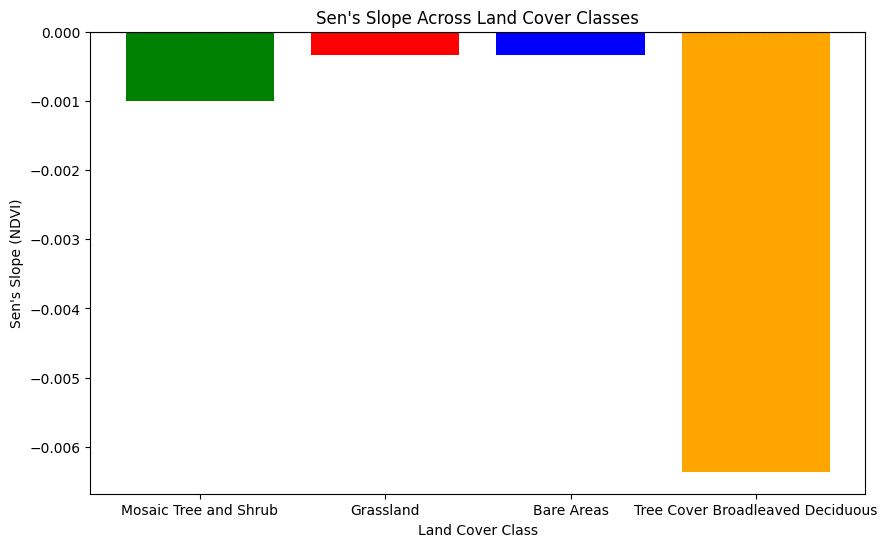

In [73]:
# Sen's Slope data
classes = ["Mosaic Tree and Shrub", "Grassland", "Bare Areas", "Tree Cover Broadleaved Deciduous"]
slope = [-0.00100, -0.00033, -0.00033, -0.00636]

plt.figure(figsize=(10, 6))
plt.bar(classes, slope, color=["green", "red", "blue", "orange"])
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Sen's Slope Across Land Cover Classes")
plt.xlabel("Land Cover Class")
plt.ylabel("Sen's Slope (NDVI)")
plt.show()

## 5. Seasonal Trends Comparison
Purpose: To compare NDVI trends across different seasons.

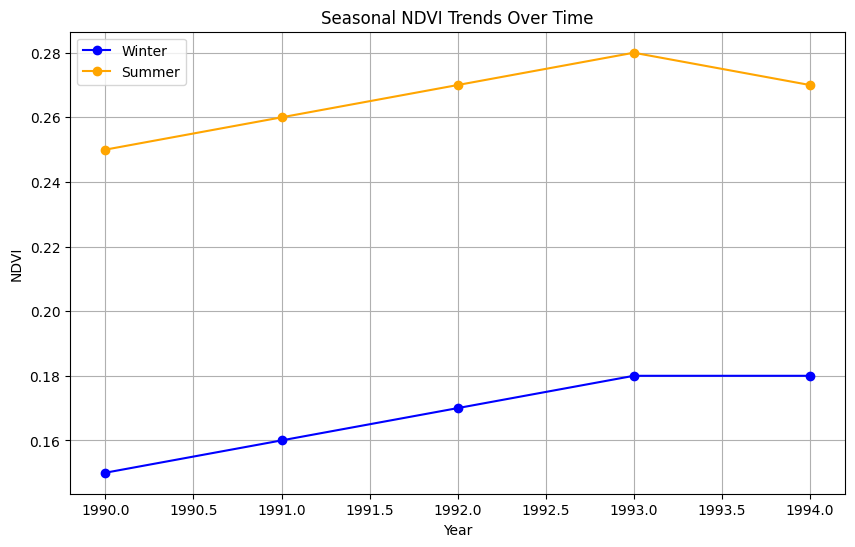

In [74]:
#  seasonal data
data = {
    "Year": [1990, 1991, 1992, 1993, 1994],
    "Winter": [0.15, 0.16, 0.17, 0.18, 0.18],
    "Summer": [0.25, 0.26, 0.27, 0.28, 0.27]
}

df = pd.DataFrame(data)

# Plot seasonal trends
plt.figure(figsize=(10, 6))
plt.plot(df["Year"], df["Winter"], label="Winter", marker='o', color='blue')
plt.plot(df["Year"], df["Summer"], label="Summer", marker='o', color='orange')

plt.title("Seasonal NDVI Trends Over Time")
plt.xlabel("Year")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.show()


## 6. Scatter Plots for NDVI vs. Climatic Variables
Purpose: To analyze relationships between NDVI and climate factors like rainfall or temperature.

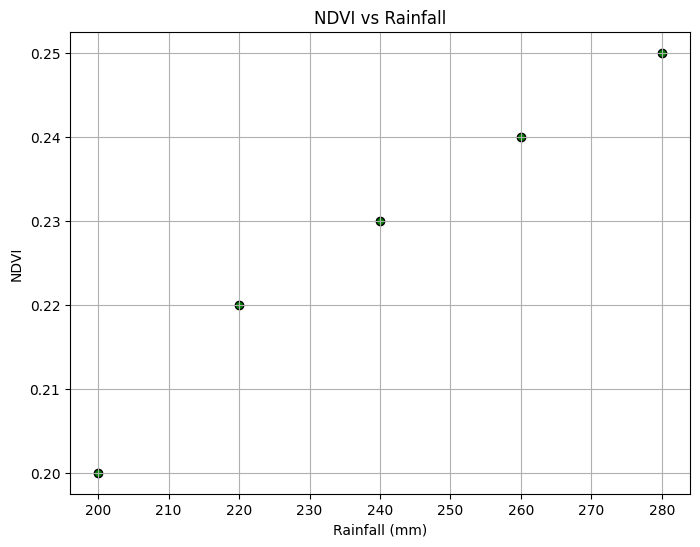

In [75]:
# Example scatterplot data
rainfall = [200, 220, 240, 260, 280]
ndvi = [0.2, 0.22, 0.23, 0.24, 0.25]

plt.figure(figsize=(8, 6))
plt.scatter(rainfall, ndvi, color='green', edgecolor='black')
plt.title("NDVI vs Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.grid(True)
plt.show()
